In [5]:
# Import dependencies

import numpy as np
import matplotlib.pyplot as plt
import os.path
import pickle
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.optimize import root_scalar, minimize_scalar, newton, least_squares
from scipy.special import erfc, ndtr, log_ndtr, erf
from scipy.integrate import quad
from scipy.interpolate import interp1d
import warnings

from matplotlib.colors import to_rgba
from matplotlib.patches import FancyArrowPatch
from matplotlib.transforms import Bbox
from mpl_toolkits.mplot3d import proj3d
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


In [6]:
# Helper functions

def log_error_bar(y, y_err):
    return [y*(1- np.exp(-y_err/y)), y*(np.exp(y_err/y) -1)]

# Generalist fixation probability in the rare specialist regime
def pfix_gen_rare(sg, xc, v):
    return xc*np.sqrt(2*v/np.pi)/sg * np.exp(-(xc-sg)**2/(2*v))

# Specialist fixation probability in the rare specialist regime, deterministic environments
def pfix_spec_rare_deterministic(sg, s_tradeoff, tau, xc, v):
    pfix_gen = xc*np.sqrt(2*v/np.pi)/sg * np.exp(-(xc-sg)**2/(2*v))
    pfix_spec = xc*np.sqrt(2*v/np.pi)/sg * np.exp(-(xc-sg -s_tradeoff*v*tau/(2*xc))**2/(2*v)) / (s_tradeoff*tau)
    pfix_spec[s_tradeoff*tau < 2.25] = pfix_gen
    return pfix_spec

_LOG_SQRT_2PI = 0.5 * np.log(2.0 * np.pi)

def _ramp(q):
    """(1 - exp(-q))/q; the q -> 0 limit is filled in from the series."""
    if q < 1e-8:
        return 1.0 - 0.5 * q
    return -np.expm1(-q) / q


def _argmax(logf, guess, lo, hi, halfwidth):
    """Refine the argmax of logf in a window around an analytic guess."""
    left, right = max(lo, guess - halfwidth), min(hi, guess + halfwidth)
    res = minimize_scalar(lambda u: -logf(u), bounds=(left, right), method="bounded", options={"xatol": 1e-11})
    return float(res.x)


def _peaked_integral(logf, u_star, scale, lo, hi, kinks, rtol, atol, limit):
    """Integrate exp(logf) over [lo, hi], with the peak height factored out."""
    span = 40.0 * scale + 12.0
    left, right = max(lo, u_star - span), min(hi, u_star + span)
    lmax = logf(u_star)
    cand = {u_star + sgn * d * scale for d in (0.05, 0.15, 0.5, 1.5, 5.0, 15.0, 40.0) for sgn in (-1.0, 1.0)}
    cand |= {u_star} | set(kinks)
    pts = sorted(p for p in cand if left < p < right)
    val, err = quad(lambda u: np.exp(logf(u) - lmax), left, right, points=pts if pts else None,
                    epsabs=atol, epsrel=rtol, limit=limit)
    return val * np.exp(lmax), err * np.exp(lmax)


def pfix_spec_rare_stochastic(sg, s_tradeoff, tau, xc, v, sigma_tau, c=100,
                              calc_type=1, rtol=1e-11, atol=0.0, limit=200, return_error=False):
    """
    Compute the fixation probability of a rare specialist in a stochastic environment
    calc_type = 1: numerical integral with the smoothed establishment weight, environmental
                   noise truncated at min(c*sigma, s_tradeoff)
    calc_type = 2: saddle point solution with no boundary term
    calc_type = 3: low-stochasticity expansion of the saddle point solution
    """

    s_tradeoff = np.asarray(s_tradeoff, dtype=float)
    sigma = s_tradeoff * sigma_tau * np.sqrt(v / (2 * tau * xc))
    if calc_type == 2:
        prefactor = np.sqrt((v + sigma**2) / (2 * np.pi))
        exp_factor = np.exp(-(xc - sg)**2 / (2 * (v + sigma**2)))
        erf_factor = (sigma**2 * xc + sg * v) / np.sqrt(2 * v * sigma**2 * (v + sigma**2))
        erf_factor = 1 + erf(erf_factor)

        return prefactor * exp_factor * erf_factor
    elif calc_type == 3:
        prefactor = np.sqrt(2 * v / np.pi)
        exp_factor = np.exp(-(xc - sg)**2 / (2 * v) * (1 - sigma**2 / v))
        return prefactor * exp_factor

    pfix_vals = np.zeros_like(s_tradeoff)
    errs = np.zeros_like(s_tradeoff)

    sv = np.sqrt(v)
    a = sg / sv
    A = xc / sv
    D = A - a

    for i in range(s_tradeoff.size):
        eps = s_tradeoff[i] * sigma_tau * np.sqrt(v / (2 * tau * xc)) / sv
        w = eps / np.sqrt(1.0 + eps * eps)
        c_eff = min(c, s_tradeoff[i] / (eps * sv))       # noise cut at min(c*sigma, s_tradeoff)
        log_tail = log_ndtr(-c_eff)

        # p2: lineages that clear xc, weight 1, noise integrated out analytically
        def logf2(t):
            lx = log_ndtr(min((t - D) / eps, c_eff))
            return -0.5 * t * t - _LOG_SQRT_2PI + lx + np.log1p(-np.exp(log_tail - lx))

        t_lo = max(-A, D - c_eff * eps)
        t_star = _argmax(logf2, np.clip(D / (1.0 + eps * eps), t_lo, A), t_lo, A, 6.0 + 6.0 * w)
        p2, e2 = _peaked_integral(logf2, t_star, w, t_lo, A, [D + c_eff * eps], rtol, atol, limit)
        p2 *= 2.0 * xc
        e2 *= 2.0 * xc

        # p1: lineages below xc, smoothed weight, founding fitness integrated out analytically
        def logf1(z):
            kappa = a + z
            X_lo = max(a - A, -z)
            X_hi = min(a + A, A - z)
            dX = X_hi - X_lo
            Xp = X_hi if kappa > 0.0 else X_lo
            return (kappa * Xp - 0.5 * (a * a + A * A) + 0.5 * z * z * (1.0 - 1.0 / (eps * eps))
                    + np.log(dX * _ramp(abs(kappa) * dX)))

        z_lo = max(-(a + A), -c_eff * eps)
        z_hi = min(2.0 * A - a, c_eff * eps)
        z_star = _argmax(logf1, np.clip(D * eps * eps / (1.0 + eps * eps), z_lo, z_hi), z_lo, z_hi, 6.0 + 6.0 * w)
        p1, e1 = _peaked_integral(logf1, z_star, w, z_lo, z_hi, [-a, D], rtol, atol, limit)
        p1 *= xc / (np.pi * eps)
        e1 *= xc / (np.pi * eps)

        pfix_vals[i] = p1 + p2
        errs[i] = e1 + e2
    return (pfix_vals, errs) if return_error else pfix_vals

def pfix_ratio_frequent_deterministic_small(sg, s_tradeoff, tau, xc, vpar, vperp):
    """Ratio <p_fix(s, st)>/<p_fix(s, 0)>, averaged over t_0."""
    def zeta(xperp, u):
        return vpar*tau*s_tradeoff/(4*sg) + xperp*vpar*u/xc - vpar*vperp*u**2/(2*xc) - vpar*vperp*tau**2/(24*xc)

    def num_integrand(t0):
        u = tau/2 - t0
        return 2/((1 + np.exp(-s_tradeoff*u))**2*(sg + zeta(vperp*u, u)))

    def den_integrand(t0):
        u = tau/2 - t0
        e = np.exp(-abs(s_tradeoff*u))
        return 2*e/((1 + e)**2*(sg + zeta(vperp*u, u)))

    return quad(num_integrand, 0, tau)[0]/quad(den_integrand, 0, tau)[0]

def pfix_frequent_deterministic_small_time(sg, s_tradeoff, tau, xc, vpar, vperp, D, t0):

    def zeta(xperp, u):
        return vpar*tau*s_tradeoff/(4*sg) + xperp*vpar*u/xc - vpar*vperp*u**2/(2*xc) - vpar*vperp*tau**2/(24*xc)

    u = tau/2 - np.minimum(t0, 2*tau - t0)
    prefactor = xc/(sg+zeta(vperp*u, u)) * np.sqrt(2*vpar/np.pi) / (1 + np.cosh(s_tradeoff*u))
    exp_term = np.exp(-(xc-sg)**2/(2*vpar) + D*s_tradeoff*u + xc*tau*s_tradeoff/(4*sg) - vperp*tau**2/24)

    return prefactor * exp_term

def pfix_frequent_deterministic_time(sg, s_tradeoff, tau, xc, vpar, D, t0, sbar = None):
    if sbar is None:
        sbar = sg

    prefactor = xc/(sbar+vpar*s_tradeoff*tau/(6*sg)) * np.sqrt(2*vpar/np.pi) #/(s_tradeoff*tau)
    A = xc - sbar - vpar*s_tradeoff*tau/(6*sg)

    if t0 is None:
        # average over t0 in [0, 2*tau]; symmetric about t0 = tau, so u sweeps [-tau/2, tau/2]
        k = D*s_tradeoff*vpar/xc
        if k == 0:
            return prefactor * np.exp(-A**2/(2*vpar))
        a = abs(A)  # difference is even in A; keeps erfc off its saturated side
        w_hi = (a + k*tau/2)/np.sqrt(2*vpar)
        w_lo = (a - k*tau/2)/np.sqrt(2*vpar)
        return prefactor * np.sqrt(2*np.pi*vpar)/(2*k*tau) * (erfc(w_lo) - erfc(w_hi))

    u = tau/2 - np.minimum(t0, 2*tau - t0)
    return prefactor * np.exp(-(A - D*s_tradeoff*vpar*u/xc)**2/(2*vpar))

def pfix_ratio_frequent_deterministic(sg, s_tradeoff, tau, vpar, ug=3e-9):
    xc = vpar/sg * np.log(sg/ug) + sg/2

    shift = vpar*s_tradeoff*tau/(6*sg)

    prefactor_rat = 1/(1+s_tradeoff*tau)
    exp_rat = np.exp(s_tradeoff*tau*(1-shift/xc)/2)

    pfix_rat = prefactor_rat * exp_rat
    pfix_rat[s_tradeoff*tau < 2.5] = 1


    return np.log(pfix_rat)

def v_est_deterministic(sg, s_tradeoff, tau, ug, N):
    LogNs = np.log(N*sg)
    LogsOverU = np.log(sg/ug)
    
    def v_root_equation(v_num):
        xc_num = v_num/sg * LogsOverU + sg/2
        return LogNs - LogsOverU + np.log(2*xc_num*np.sqrt(2*v_num/np.pi)) - np.log(v_num) - 1/(2*v_num) * (xc_num - sg - v_num*s_tradeoff*tau/(6*sg))**2
    
    v_orig = 2*sg**2 * LogNs / LogsOverU**2
    sol = root_scalar(v_root_equation, x0=float(v_orig), method='secant')
    v_numeric = sol.root if sol.converged else None
    xc_numeric = v_numeric/sg * LogsOverU + sg/2 if v_numeric is not None else None
    return v_numeric, xc_numeric

def log_survival(z, mu, sigma, c):
    """
    Semianalytic approximation to the survival function S(z) of xi^*, for 0 <= z < c
    mu = effective mean, sigma^2 = effective variance, c = cutoff
    """
    z = np.asarray(z, dtype=float)
    t = np.maximum(z / c, 0.)
    wall = np.full(t.shape, -100.) # Floor for z > c
    np.log1p(-t, out=wall, where=t < 1.)
    return log_ndtr(-(z - mu) / sigma) - wall**2

def analytic_mu(sg, s_tradeoff, tau, xc, vpar, vperp, sigma_tau):
    return (s_tradeoff * sigma_tau / np.sqrt(np.pi) * np.sqrt(vpar / (xc * tau)) * (xc / sg)
            - vperp * sigma_tau**2 / (2. * tau))

def xi_typ_ansatz(sg, s_tradeoff, tau, xc, vpar, sigma_tau):
    return np.sqrt(2/np.pi) * np.sqrt(3/8 - 1/np.pi) * xc * s_tradeoff * sigma_tau * np.sqrt(vpar/(tau*xc)) / sg

def analytic_cutoff(sg, s_tradeoff, xc, vpar, vperp, xperp):
    q = np.exp(-sg / xc)
    return vpar / (2. * vperp * xc) * (q * np.asarray(xperp)**2
                                    + s_tradeoff**2 * q**2 / (1. - q)**2)

def fit_sigma_eff(sg, s_tradeoff, tau, xc, vpar, vperp, sigma_tau, x_vals_all, surv_vals_all, xperp_vals):
    """Fit sigma_eff from empirical survival data on each xperp slice."""
    xperp = np.asarray(xperp_vals, dtype=float)
    xs = [np.asarray(x, dtype=float) for x in x_vals_all]
    ls = [np.log(np.asarray(S, dtype=float)) for S in surv_vals_all]
    mu = analytic_mu(sg, s_tradeoff, tau, xc, vpar, vperp, sigma_tau)
    cs = np.array([analytic_cutoff(sg, s_tradeoff, xc, vpar, vperp, xp) for xp in xperp])

    sigma = np.zeros(len(xperp))
    for j in range(len(xperp)):
        sol = least_squares(lambda p: log_survival(xs[j], mu, np.exp(p[0]), cs[j]) - ls[j],
                            [np.log(np.std(xs[j]))], xtol=1e-12, ftol=1e-12, max_nfev=400)
        sigma[j] = np.exp(sol.x[0])
    return sigma

def pfix_frequent_stochastic_integral(sg, s_tradeoff, tau, xc, vpar, vperp, sigma_tau, D,
                                      xperp_vals, sigma_vals, sbar=None,
                                      n_xperp=3., n_scan=2000, win=3.):
    """
    Estimates pfix in the frequent-specialists regime in a stochastic environment
    Uses a quadratic saddle point fit for xperp integrand bsaed on supplied sigma values
    D = mutation identity, 0 for generalist and +-1 for specialist
    """
    if sbar is None:
        sbar = sg
    xperp = np.asarray(xperp_vals, dtype=float)
    sigma = np.asarray(sigma_vals, dtype=float)
    mu = analytic_mu(sg, s_tradeoff, tau, xc, vpar, vperp, sigma_tau)
    T = xc * xc / (2. * vpar)

    # Quadrature helpers for inner integral
    gl_x, gl_w = np.polynomial.legendre.leggauss(16)
    t_offsets = np.concatenate([[0.], np.geomspace(0.05, 50., 16)])

    def log_xpar_integral(sigma_j, c_j):
        log_S = lambda z: log_survival(z, mu, sigma_j, c_j)

        # Inner integral over environmental stochasticity
        def log_xi_integral(xpar):
            y_hi = min(xc, xpar + c_j)
            if y_hi <= 0.:
                return -np.inf

            # Gauss-Legendre quadrature over allowed range
            t_lo = (xc * xc - y_hi * y_hi) / (2. * vpar)
            edges = np.unique(np.clip(np.append(t_lo + t_offsets, T), t_lo, T))
            half = 0.5 * (edges[1:] - edges[:-1])[:, None]
            mid = 0.5 * (edges[1:] + edges[:-1])[:, None]
            t_nodes = mid + half * gl_x[None, :]
            weights = half * gl_w[None, :]

            y_nodes = np.sqrt(np.maximum(xc * xc - 2. * vpar * t_nodes, 0.))
            log_bulk = -t_nodes + log_S(y_nodes - xpar)
            shift = float(log_bulk.max())
            bulk = shift + np.log(np.sum(weights * np.exp(log_bulk - shift)))
            return np.logaddexp(bulk, -T + float(log_S(-xpar)))

        # Overall integrand over mutant's landing xpar
        def log_integrand(xpar):
            xa = np.atleast_1d(xpar)
            out = (-(xa - sbar)**2 / (2. * vpar)
                   + np.array([log_xi_integral(float(xv)) for xv in xa]))
            return out.reshape(np.shape(xpar))

        xpar_lo, xpar_hi = max(sbar - xc, -c_j), sbar + xc

        # Identify peak location for quadrature
        scan = np.linspace(xpar_lo, xpar_hi, n_scan)
        xpar_pk = float(scan[np.argmax(-(scan - sbar)**2 / (2. * vpar) + log_S(xc - scan))])

        w = np.sqrt(vpar) / max(1., abs(xc - sbar) / np.sqrt(vpar))
        offsets = np.array([-8., -4., -2., -1., -.5, 0., .5, 1., 2., 4., 8.])
        stencil = np.unique(np.clip(xpar_pk + w * offsets, xpar_lo, xpar_hi))
        log_stencil = log_integrand(stencil)
        L_max = float(np.max(log_stencil))
        xpar_pk = float(stencil[np.argmax(log_stencil)])

        # Perform outer integral
        integrand = lambda xpar: float(np.exp(log_integrand(xpar) - L_max))
        breaks = [xpar_pk] if xpar_lo < xpar_pk < xpar_hi else None
        val, _ = quad(integrand, xpar_lo, xpar_hi, points=breaks,
                      limit=400, epsabs=0., epsrel=1e-9)
        return L_max + np.log(val)

    def log_xperp_integral(log_xpar_vals):
        # mirror onto xperp < 0, fit a log-quadratic near the peak, integrate analytically
        xperp_full = np.concatenate([-xperp[:0:-1], xperp])
        G = (np.concatenate([log_xpar_vals[:0:-1], log_xpar_vals])
             - (xperp_full - D * s_tradeoff)**2 / (2. * vperp))

        sel = G > G.max() - win
        if np.sum(sel) < 5:
            sel = G >= np.sort(G)[-5]
            warnings.warn(f"fit window held fewer than 5 points; widened to {np.sum(sel)}",
                          RuntimeWarning)

        y = G[sel]
        a2, a1, a0 = np.polyfit(xperp_full[sel], y, 2, w=np.exp(0.5 * (y - y.max())))
        if a2 >= 0.:
            warnings.warn("no interior peak in xperp; check n_xperp and the sigma_eff trend",
                          RuntimeWarning)
            return np.nan

        xperp_pk = -a1 / (2. * a2)
        sigma_xperp = 1. / np.sqrt(-2. * a2)
        G_pk = a0 - a1**2 / (4. * a2)

        if not xperp_full[sel].min() < xperp_pk < xperp_full[sel].max():
            warnings.warn(f"fitted peak {xperp_pk:.4g} lies outside the fit window",
                          RuntimeWarning)

        xperp_lim = n_xperp * xc
        frac = (ndtr((xperp_lim - xperp_pk) / sigma_xperp)
                - ndtr((-xperp_lim - xperp_pk) / sigma_xperp))
        if frac < 0.5:
            warnings.warn(f"truncation dominates (frac = {frac:.3g}); increase n_xperp",
                          RuntimeWarning)

        return (-np.log(2. * np.pi * np.sqrt(vpar * vperp)) + G_pk
                + np.log(sigma_xperp) + 0.5 * np.log(2. * np.pi) + np.log(frac))

    log_xpar_vals = np.array([
        log_xpar_integral(sigma[j],
                            float(analytic_cutoff(sg, s_tradeoff, xc, vpar, vperp, xperp[j])))
        for j in range(len(xperp))
    ])
    return np.log(2 * xc) + log_xperp_integral(log_xpar_vals)

def fit_sigma_quadratic(xperp_vals, sigma_vals, n):
    """Fit sigma_eff = sigma0 + xperp^2/alpha to the first n slices."""
    xperp = np.asarray(xperp_vals, dtype=float)
    sigma = np.asarray(sigma_vals, dtype=float)
    slope, intercept = np.polyfit(xperp[:n]**2, sigma[:n], 1)
    return float(intercept), float(1. / slope)

def pfix_ratio_frequent_stochastic_simple(sg, s_tradeoff, tau, xc, vpar, sigma_tau, sbar = None):
    # Estimates ratio pfix(sbar, s_tradeoff)/pfix(sbar, 0) in the frequent-specialists regime in a stochastic environment
    if sbar is None: sbar = sg
    xi_typ = np.sqrt(2/np.pi) * np.sqrt(3/8 - 1/np.pi) * np.sqrt(vpar*xc/tau) * sigma_tau * s_tradeoff / sg
    return np.exp((xc/vpar)*(sg*xi_typ/xc + sbar - sg))

def pfix_frequent_stochastic_semianalytic(sg, s_tradeoff, tau, xc, vpar, vperp, sigma_tau, D,
                                          sigma0, alpha, sbar=None,
                                          n_slices=100, xperp_max=1.0,
                                          n_xperp=3., n_scan=2000, win=3.):
    """Run pfix_frequent_stochastic_integral, with sigma_eff from the quadratic ansatz."""
    xperp_vals = np.linspace(0., xperp_max, n_slices)
    sigma_vals = sigma0 + xperp_vals**2 / alpha
    return pfix_frequent_stochastic_integral(sg, s_tradeoff, tau, xc, vpar, vperp, sigma_tau, D,
                                             xperp_vals, sigma_vals, sbar=sbar,
                                             n_xperp=n_xperp, n_scan=n_scan, win=win)

def sigma0_ansatz(sg, s_tradeoff, tau, xc, vpar, sigma_tau):
    return np.sqrt(vpar*xc/tau) * sigma_tau * s_tradeoff / sg

def alpha_ansatz(sg, s_tradeoff, tau, xc, vpar, sigma_tau):
    return np.sqrt(xc*tau/vpar) * xc*s_tradeoff / (sg*sigma_tau)

def pfix_frequent_stochastic_analytic(sg, s_tradeoff, tau, xc, vpar, vperp, sigma_tau, D,
                                          sigma0_coeff, alpha_coeff, sbar=None,
                                          n_slices=100, xperp_max=1.0,
                                          n_xperp=3., n_scan=2000, win=3.):
    """Run pfix_frequent_stochastic_integral_semianalytic, generating sigma0 and alpha from fit coefficients."""
    sigma0 = sigma0_coeff * sigma0_ansatz(sg, s_tradeoff, tau, xc, vpar, sigma_tau)
    alpha = alpha_coeff * alpha_ansatz(sg, s_tradeoff, tau, xc, vpar, sigma_tau)
    return pfix_frequent_stochastic_semianalytic(sg, s_tradeoff, tau, xc, vpar, vperp, sigma_tau, D,
                                          sigma0, alpha, sbar, n_slices, xperp_max,
                                          n_xperp, n_scan, win)


def v_est_stochastic(sg, s_tradeoff, tau, sigma_tau, ug, N):
    """Solve for v self-consistently using analytic_mu"""
    L = np.log(sg / ug)
    v0 = 2. * sg**2 * np.log(N * sg) / L**2

    def resid(lv):
        v = np.exp(lv)
        xc = (v / sg) * L + sg / 2.
        xi_adj = xi_typ_ansatz(sg, s_tradeoff, tau, xc, v, sigma_tau)
        return (np.log(2. * N * ug * xc) + 0.5 * np.log(2. / (np.pi * v))
                - (xc - sg - xi_adj)**2 / (2. * v))

    sol = root_scalar(resid, x0=np.log(v0), method='newton', xtol=1e-14, rtol=1e-12)
    return np.exp(sol.root), np.exp(sol.root)/sg * L + sg/2

def vperp_est_stochastic(sg, s_tradeoff, tau, vpar, sigma_tau, ug, long_cycle = False):
    xc = vpar/sg * np.log(sg/ug) + sg/2

    sg_eff = 2*vpar*tau if long_cycle else sg
    s_tradeoff_eff = s_tradeoff * 2*vpar * tau/sg if long_cycle else s_tradeoff
    sigma_eff = sigma_tau * np.sqrt(sg_eff/(vpar*tau))
    return s_tradeoff_eff / sigma_eff * np.sqrt(2/np.pi) * (5/3 * np.sqrt(xc/sg_eff) - 1.46)

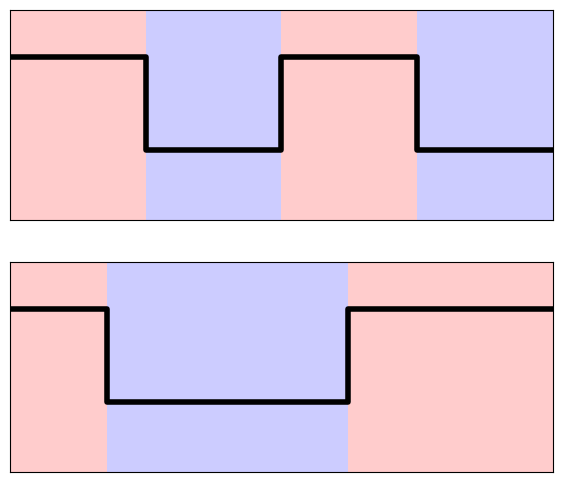

In [7]:
# FIGURE 1A, environment schematic

n_periods = 2
period = 1.0
y_high, y_low = 2.0, 1.0
sigma = 0.2
rng = np.random.default_rng()

T = n_periods * period


def draw(ax, edges, levels):
    for x0, x1, y in zip(edges[:-1], edges[1:], levels):
        ax.fill_between([x0, x1], 0, 1.25*y_high, color='red' if y == y_high else 'blue', alpha=0.2, linewidth=0)
    ax.plot(np.repeat(edges, 2)[1:-1], np.repeat(levels, 2), color='black', linewidth=4)
    ax.set_xlim(0, T)
    ax.set_ylim(0.25, 1.25 * y_high)
    ax.set_xticks([])
    ax.set_yticks([])

def levels_for(edges):
    return np.where(np.arange(len(edges) - 1) % 2 == 0, y_high, y_low)

# Accumulate jittered half-periods until the total time is covered, then clip
jittered = [0.0]
while jittered[-1] < T:
    jittered.append(jittered[-1] + period / 2 + rng.normal(0, sigma))
jittered[-1] = T
jittered = np.array(jittered)

regular = np.arange(2 * n_periods + 1) * (period / 2)

fig, axes = plt.subplots(2, 1, figsize=(7, 6))
draw(axes[0], regular, levels_for(regular))
draw(axes[1], jittered, levels_for(jittered))

#plt.savefig(r'Figures\1A_Environments.pdf', format='pdf')
plt.show()


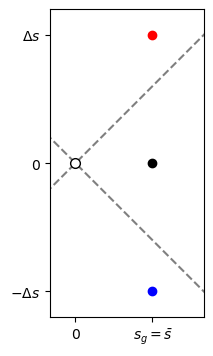

In [8]:
# FIGURE 1C, joint DFE schematic

sg = 0.03
s_tradeoff = 0.05

plt.figure(figsize=(4,4))

plt.plot(sg, 0, marker="o", color="black")
plt.plot(sg, s_tradeoff, marker="o", color="red")
plt.plot(sg, -s_tradeoff, marker="o", color="blue")



plt.plot([-0.06, 0.08], [-0.06, 0.08], color="gray", linestyle="--")
plt.plot([-0.06, 0.08], [0.06, -0.08], color="gray", linestyle="--")
plt.plot(0,0,marker="o",color='black',markerfacecolor='white',markersize=7)
plt.xlim([-0.01, 0.05])
plt.ylim([-0.06, 0.06])
plt.gca().set_aspect("equal", adjustable="box")
plt.xticks([0,sg],["0", "$s_g = \\bar{s}$"])
plt.yticks([-s_tradeoff,0,s_tradeoff],["$-\Delta s$","0","$\Delta s$"])

#plt.savefig(r'Figures\1B_Toy_DFE.pdf', format='pdf')
plt.show()


In [ ]:
# FIGURE 1C, specialist advantage in successive mutation and rapid adaptation regime

pfix_ratios = np.zeros((40,2,2))

sg = 0.03
ug = 3e-6
us = 3e-6
period = 200
N_vals = [1e4, 1e10]
s_tradeoff_vals = np.round(np.linspace(0.005, 0.2, 40), 4)

for i in range(0,len(s_tradeoff_vals)):
    for j in range(0,len(N_vals)):
        fname = 'Fig1-2_Data/N_' + str(N_vals[j]) + '_us_' + str(us) + '_ss_' + str(s_tradeoff_vals[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_0.pickle'

        if os.path.isfile(fname):
            with open(fname,'rb') as file:
                data = pickle.load(file)
        else:
            print(fname)
            continue

        pfix_gen = np.polyfit(np.array(data['times'])[100:], np.array(data['mut_freqs1'])[100:], 1)[0] / (N_vals[j] * ug)
        pfix_spec = np.polyfit(np.array(data['times'])[100:], np.array(data['mut_freqs2'])[100:] + np.array(data['mut_freqs3'])[100:], 1)[0] / (N_vals[j] * us)

        pfix_ratios[i,j,0] = pfix_spec/pfix_gen

        fname = 'Fig1-2_Data/N_' + str(N_vals[j]) + '_us_' + str(us) + '_ss_' + str(s_tradeoff_vals[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_0.5.pickle'

        if os.path.isfile(fname):
            with open(fname,'rb') as file:
                data = pickle.load(file)
        else:
            print(fname)
            continue

        pfix_gen = np.polyfit(np.array(data['times'])[100:], np.array(data['mut_freqs1'])[100:], 1)[0] / (N_vals[j] * ug)
        pfix_spec = np.polyfit(np.array(data['times'])[100:], np.array(data['mut_freqs2'])[100:] + np.array(data['mut_freqs3'])[100:], 1)[0] / (N_vals[j] * us)

        pfix_ratios[i,j,1] = pfix_spec/pfix_gen

C:\Users\johnd\AppData\Local\Temp\ipykernel_28960\4025414397.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('Dark2', 3)


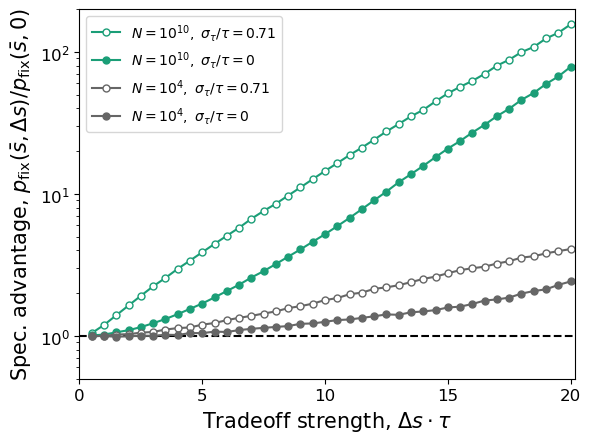

In [10]:
tau = period/2

colors = cm.get_cmap('Dark2', 3)
colors = [mcolors.to_rgba(colors(i)) for i in range(colors.N)]

plt.axhline(y=1, color='black', linestyle='--')

plt.plot(s_tradeoff_vals*tau, pfix_ratios[:, 1, 1], marker='o', markersize=5, label=r'$N = 10^{10},~\sigma_\tau/\tau = 0.71$', color=colors[0], markerfacecolor='white')
plt.plot(s_tradeoff_vals*tau, pfix_ratios[:, 1, 0], marker='o', markersize=5, label=r'$N = 10^{10},~\sigma_\tau/\tau = 0$', color=colors[0])
plt.plot(s_tradeoff_vals*tau, pfix_ratios[:, 0, 1], marker='o', markersize=5, label=r'$N = 10^4,~\sigma_\tau/\tau = 0.71$', color=colors[2], markerfacecolor='white')
plt.plot(s_tradeoff_vals*tau, pfix_ratios[:, 0, 0], marker='o', markersize=5, label=r'$N = 10^4,~\sigma_\tau/\tau = 0$', color=colors[2])

plt.legend()

plt.xlim([0,0.202*tau])
plt.ylim([0.5,200])
plt.xlabel('Tradeoff strength, $\Delta s \cdot \\tau$',fontsize=15)
plt.ylabel('Spec. advantage, $p_{\mathrm{fix}}(\\bar{s},\Delta s)/p_{\mathrm{fix}}(\\bar{s},0)$',fontsize=15)
plt.xticks([0,5,10,15,20],fontsize=12)
plt.yticks([1,10,100],fontsize=12)
plt.yscale('log')

#plt.savefig(r'Figures\1C_Pfix_Two_Regimes.pdf', format='pdf')
plt.show()

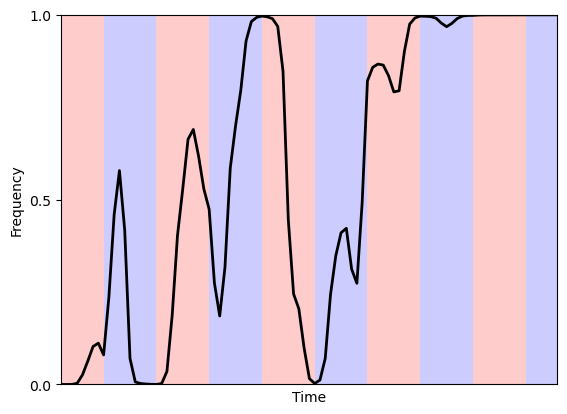

In [ ]:
# FIGURE 1D, sample trajectory

fname = 'Fig1-2_Data\\N_10000000000.0_us_3e-06_ss_0.15_ug_3e-06_sg_0.03_tau_200_dtau_0_testfreqs.pickle'

with open(fname, 'rb') as file:
    data = pickle.load(file)

fix_mask = np.logical_and(np.array(data['fixations']) == 1, np.array(data['mut_types']) != 0)
start_list = np.array(data['fixation_starts'])[fix_mask]
time_list = np.array(data['fixation_times'])[fix_mask]
adj_list = np.array(data['pfix_adjustments'])[fix_mask]
mut_type_list = np.array(data['mut_types'])[fix_mask]


target = np.argsort(adj_list)[-2]
time_inds = np.logical_and(np.array(data['times']) >= start_list[target], np.array(data['times']) <= start_list[target] + time_list[target])

t = np.array(data['times'])[time_inds]
t = t - t[0]
states = np.array(data['states'])[time_inds]

# right edge of the last chunk, extrapolated from the final sampling interval
t_edges = np.append(t, 2*t[-1] - t[-2])
breaks = np.concatenate(([0], np.nonzero(np.diff(states))[0] + 1, [len(states)]))

for i0, i1 in zip(breaks[:-1], breaks[1:]):
    if mut_type_list[target] == 1:
        plt.axvspan(t_edges[i0], t_edges[i1], color='blue' if states[i0] > 0 else 'red', alpha=0.2, linewidth=0)
    elif mut_type_list[target] == -1:
        plt.axvspan(t_edges[i0], t_edges[i1], color='red' if states[i0] > 0 else 'blue', alpha=0.2, linewidth=0)

plt.plot(t, np.array(data['test_freqs'])[time_inds],color='black',linewidth=2)
plt.xlim([0, t[-1]])
plt.xlabel('Time')
plt.xticks([])
plt.ylabel('Frequency')
plt.yticks([0,0.5,1])
plt.ylim([0,1])

#plt.savefig(r'Figures\1D_Sample_Trajectory.pdf', format='pdf')
plt.show()

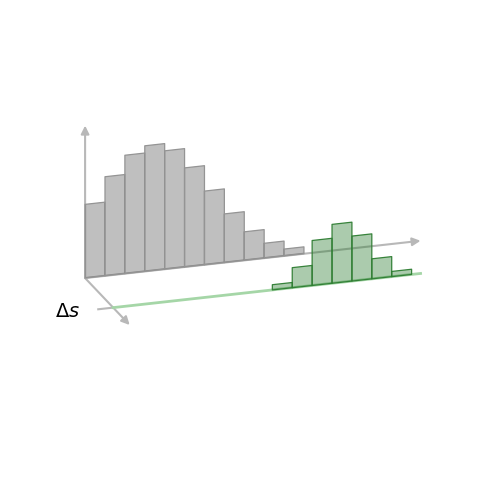

In [12]:
# FIGURE 2A, traveling wave schematic

v = 0.0015                      # variance of the back wave
xc = 0.1                        # nose of the back wave
binWidth = 2*xc/15              # bin centered on the mean, bin edge on the nose
xL = -3.5*binWidth              # origin, on a bin edge
sf = 0.22                       # size of the front wave relative to the back one
xf = 8*binWidth                 # center of the front wave, on a bin center
zf = -0.85                      # depth of the front wave
zTop, zTip = 12.5, zf - 0.5     # axis tips in frequency and depth
tickLen, overhang = 0.01, 0.006

xLim, yLim, zLim = (xL - 0.01, 0.122), (-2.8, 0.15), (-0.5, zTop + 0.5)
boxAspect, elev, azim = (1.6, 1.8, 1.0), 20, -108
axisGray, green = '0.72', '#2e7d32'
paleGreen = '#a5d6a7'
backEdgeGray = '0.58'   # bar outlines, a little darker than the 0.25-alpha black fill


class Arrow3D(FancyArrowPatch):
    """Straight arrow between two points in 3D data coordinates."""
    def __init__(self, xs, ys, zs, **kwargs):
        super().__init__((0, 0), (0, 0), **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None):
        xp, yp, zp = proj3d.proj_transform(*self._verts3d, self.axes.M)
        self.set_positions((xp[0], yp[0]), (xp[1], yp[1]))
        return np.min(zp)


def wave(x, center, var, scale):
    """Gaussian with peak height scaled by `scale`."""
    return scale*np.exp(-(x - center)**2/(2*var))/np.sqrt(2*np.pi*var)


def binned(xMin, xMax, center, var, scale):
    """Edges and heights of the bins whose centers fall in [xMin, xMax]."""
    k = np.arange(np.ceil(xMin/binWidth), np.floor(xMax/binWidth) + 1)
    return binWidth*np.append(k - 0.5, k[-1] + 0.5), wave(binWidth*k, center, var, scale)


def histogram(ax, edges, heights, depth, faceColor, edgeColor, zorder):
    """Flat semi-transparent histogram standing in the plane y = depth."""
    pc = Poly3DCollection([[(x0, depth, 0), (x1, depth, 0), (x1, depth, h), (x0, depth, h)]
                           for x0, x1, h in zip(edges[:-1], edges[1:], heights)], zorder=zorder)
    pc.set_facecolor(faceColor)
    pc.set_edgecolor(edgeColor)
    pc.set_linewidth(0.9)
    ax.add_collection3d(pc)


backEdges, backHeights = binned(xL, xc, 0.0, v, 1.0)

# front wave truncated where it falls to the height of the back wave's nose
halfWidth = np.sqrt(-2*sf*v*np.log(wave(xc, 0.0, v, 1.0)/wave(xf, xf, sf*v, sf)))
frontEdges, frontHeights = binned(xf - halfWidth, xf + halfWidth, xf, sf*v, sf)

# fitness axis ends at the screen position of the green baseline's end
xGreen = frontEdges[-1] + overhang
xTip = xGreen - zf/np.tan(np.radians(azim))*boxAspect[1]/boxAspect[0]*np.ptp(xLim)/np.ptp(yLim)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.set_proj_type('ortho')
ax.set_box_aspect(boxAspect)
ax.set_axis_off()
ax.computed_zorder = False

arrowKw = dict(arrowstyle='-|>', mutation_scale=12, color=axisGray, linewidth=1.5, shrinkA=0, shrinkB=0, zorder=1)
ax.add_artist(Arrow3D([xL, xTip], [0, 0], [0, 0], **arrowKw))
ax.add_artist(Arrow3D([xL, xL], [0, 0], [0, zTop], **arrowKw))
ax.add_artist(Arrow3D([xL, xL], [0, zTip], [0, 0], **arrowKw))

ax.plot([xL - tickLen, xL], [zf, zf], [0, 0], color=axisGray, linewidth=1.5, zorder=1)
ax.text(xL - 2.2*tickLen, zf, 0, '$\\Delta s$', fontsize=14, ha='right', va='center')
ax.plot([xL, xGreen], [zf, zf], [0, 0], color=paleGreen, linewidth=2, zorder=2)

histogram(ax, backEdges, backHeights, 0.0, to_rgba('black', 0.25), backEdgeGray, 3)
histogram(ax, frontEdges, frontHeights, zf, to_rgba(green, 0.40), to_rgba(green, 0.95), 4)

ax.set_xlim(xLim)
ax.set_ylim(yLim)
ax.set_zlim(zLim)
ax.view_init(elev=elev, azim=azim)

# crop to the drawn content, since the 3D axes leave large empty margins
fig.canvas.draw()
img = np.asarray(fig.canvas.buffer_rgba())
rows, cols = np.where(np.any(img[:, :, :3] < 250, axis=2))
pad, dpi, height = 0.1, fig.dpi, img.shape[0]
bbox = Bbox.from_extents(cols.min()/dpi - pad, (height - rows.max())/dpi - pad,
                         (cols.max() + 1)/dpi + pad, (height - rows.min())/dpi + pad)



#fig.savefig('Figures\\2A_Fitness_Wave_Schematic.pdf', format='pdf', bbox_inches=bbox)
plt.show()


In [ ]:
# FIGURE 2B, time-dependent rare specialist fixation probability

ug = 3e-6
N = 1e10

fname = 'Fig1-2_Data/N_' + str(1e10) + '_us_rare_ss_0.1_ug_3e-06_sg_0.03_tau_200_dtau_0.pickle'
with open(fname,'rb') as file:
    data = pickle.load(file)

fixations = np.array(data['fixations'])
pfix_adjustments = np.array(data['pfix_adjustments'])
times = np.array(data['times'])
mut_freqs1 = np.array(data['mut_freqs1'])
states = np.array(data['states'])
fix_starts = np.array(data['fixation_starts'])


pfix_spec = (fixations * pfix_adjustments).sum() / len(fixations)
pfix_gen = np.polyfit(times[100:], mut_freqs1[100:], 1)[0] / (N * ug)


fname = 'Fig1-2_Data/N_' + str(1e10) + '_us_rare_ss_0.1_ug_3e-06_sg_0.03_tau_200_dtau_0.25.pickle'
with open(fname,'rb') as file:
    data = pickle.load(file)

pfix_spec_2 = (np.array(data['fixations']) * np.array(data['pfix_adjustments'])).sum() / len(np.array(data['fixations']))


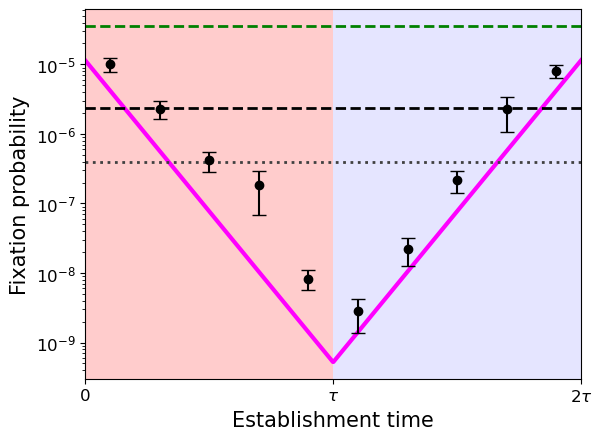

In [14]:
s_tradeoff = 0.1
ug = 3e-6
sg = 0.03
period = 200
N = 1e10
tau = period/2

v = 2*sg**2*np.log(N*sg)/np.log(sg/ug)**2
xc = 2*sg*np.log(N*sg)/np.log(sg/ug)

est_time_vals = np.linspace(0,2*tau,1000)
pfix_vals = 2*xc*np.sqrt(2*v/np.pi)/(2*sg*s_tradeoff*tau)*np.exp(-(xc-sg)**2/(2*v)+s_tradeoff*tau/2-s_tradeoff*np.minimum(est_time_vals, 2*tau-est_time_vals))


R = np.zeros(states.shape)
for i in range(len(R)-1):
    R[i+1] = R[i] + 1
    if states[i+1] == 1 and states[i] == -1:
        R[i+1] = 0

bin_edges = np.linspace(0,2*tau,11)
pfix_t = np.zeros(len(bin_edges)-1)
pfix_t_err = np.zeros(len(bin_edges)-1)

for i in range(len(bin_edges)-1):
    filt = np.logical_and(R[fix_starts] >= bin_edges[i], R[fix_starts] < bin_edges[i+1])
    pfix_t[i] = (fixations[filt] * pfix_adjustments[filt]).sum() / len(fixations[filt])
    pfix_t_err[i] = (fixations[filt] * pfix_adjustments[filt]).std() / np.sqrt(len(fixations[filt]))

plt.plot(est_time_vals, pfix_vals, color='magenta', linewidth=3)
plt.errorbar(bin_edges[:-1]/2 + bin_edges[1:]/2, pfix_t, yerr=pfix_t_err, fmt='o', color='black', capsize=5)

plt.axvspan(0, tau, facecolor='red', alpha=0.2)
plt.axvspan(tau, 2*tau, facecolor='blue', alpha=0.1)

plt.yscale('log')
plt.xlabel('Establishment time',fontsize=15)
plt.ylabel('Fixation probability',fontsize=15)
plt.xlim([0,2*tau])
plt.xticks([0, tau, 2*tau], ['0', r'$\tau$', r'$2\tau$'],fontsize=12)
plt.yticks(fontsize=12)

plt.axhline(y=pfix_spec, color='black', linestyle='--',linewidth=2)

plt.axhline(y=pfix_gen, color=[0.25, 0.25, 0.25], linestyle=':',linewidth=2)

plt.axhline(y=pfix_spec_2, color='green', linestyle='--',linewidth=2)

#plt.savefig(r'Figures\2B_Fixation_Prob_Time.pdf', format='pdf')

plt.show()

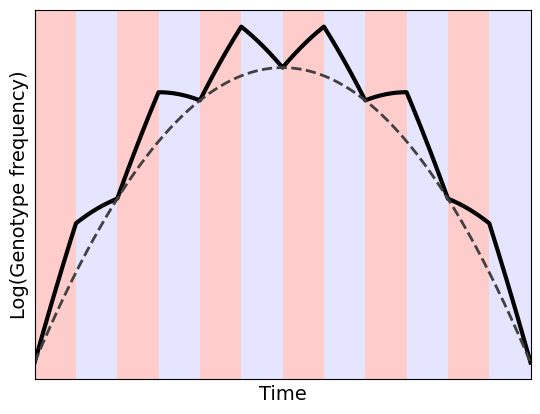

In [15]:
# FIGURE 2C, genotype trajectory schematic

s0 = 0.3
s_tradeoff = 0.15
v = 0.00025

t = np.arange(24000)/10
tau = 200
state = np.ones_like(t)
for i in range(len(t)):
    if (t[i] // tau) % 2 == 1:
        state[i] = -1

s_traj = s0 + s_tradeoff*state - v*t
s_traj_gen = s0 - v*t
logf = np.zeros_like(t)
logf2 = np.zeros_like(t)

logf[0] = 0.01
logf2[0] = 0.01

for i in range(1,len(logf)):
    logf[i] = logf[i-1] + s_traj[i-1]*(t[i]-t[i-1])
    logf2[i] = logf2[i-1] + s_traj_gen[i-1]*(t[i]-t[i-1])


plt.plot(t, logf, color='black', linewidth=3)
plt.plot(t, logf2, color=0.25*np.array([1,1,1]), linestyle='--',linewidth=2)
plt.xlabel('Time',fontsize=14)
plt.ylabel('Log(Genotype frequency)',fontsize=14)
plt.xticks([])
plt.yticks([])

i = 0
while i < len(t) - 1:
    if state[i] == 1:
        j = next((j for j in range(i + 1, len(state)) if state[j] == -1), len(t)-1)
        plt.axvspan(t[i], t[j], facecolor='red', alpha=0.2)
        i = j
    else:
        j = next((j for j in range(i + 1, len(state)) if state[j] == 1), len(t)-1)
        plt.axvspan(t[i], t[j], facecolor='blue', alpha=0.1)
        i = j

plt.xlim([t[0],t[-1]])
#plt.savefig(r'Figures\1B_Frequency_Periodic.pdf', format='pdf')
plt.show()



In [ ]:
# FIGURE 3A, rare specialist advantage

pfix_ratios = np.zeros((19,3))

sg = 0.02
ug = 3e-9
N = 1e20
period_vals = [200,300,400]
s_tradeoff_vals = [0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05, 0.055, 0.06, 0.065, 0.07, 0.075, 0.08, 0.085, 0.09, 0.095, 0.1]

for i in range(0,len(s_tradeoff_vals)):
    for j in range(0,len(period_vals)):
        all_fixations = []
        all_pfix_adjustments = []
        all_pfix_gens = []

        for ind in range(0,10):
            fname = 'Fig3_Data/N_' + str(N) + '_us_rare_ss_' + str(s_tradeoff_vals[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period_vals[j]) + '_dtau_0_small_output_' + str(ind) + '.pickle'
    
            if os.path.isfile(fname):
                with open(fname,'rb') as file:
                    data = pickle.load(file)
            else:
                print(fname)
                continue

            all_fixations.extend(data['fixations'])
            all_pfix_adjustments.extend(data['pfix_adjustments'])
            all_pfix_gens.append(data['rate_gen']/(N*ug))
            
        pfix_gen = np.mean(all_pfix_gens)
        pfix_spec = (np.array(all_fixations) * np.array(all_pfix_adjustments)).sum() / len(all_fixations)

        pfix_ratios[i,j] = pfix_spec/pfix_gen

C:\Users\johnd\AppData\Local\Temp\ipykernel_28960\3153214427.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('Dark2', 3)
C:\Users\johnd\AppData\Local\Temp\ipykernel_28960\2529572078.py:13: RuntimeWarning: divide by zero encountered in divide
  pfix_spec = xc*np.sqrt(2*v/np.pi)/sg * np.exp(-(xc-sg -s_tradeoff*v*tau/(2*xc))**2/(2*v)) / (s_tradeoff*tau)


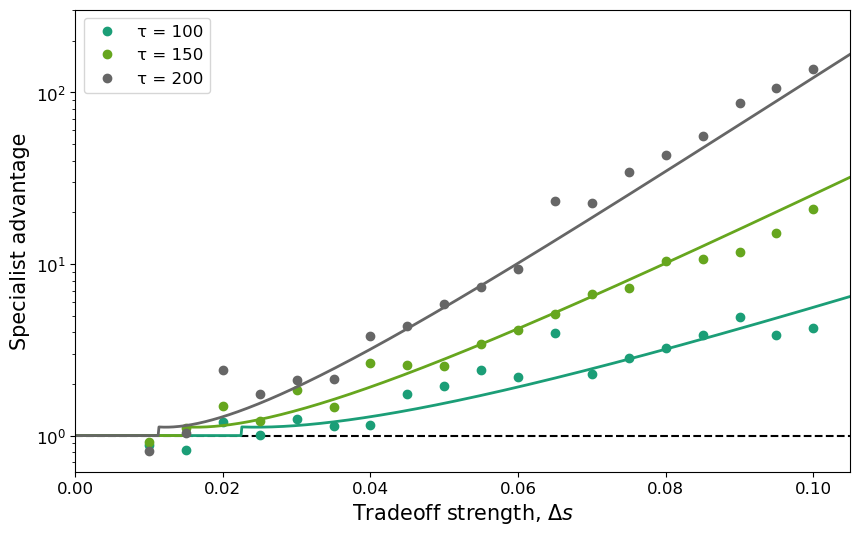

In [17]:
# Define the colors for the plots 
colors = cm.get_cmap('Dark2', 3)

v = 2*sg**2*np.log(N*sg)/np.log(sg/ug)**2
xc = v/sg * np.log(sg/ug) + sg/2

# Create the plot
plt.figure(figsize=(10, 6))

plt.plot([0,0.11],[1,1],color='black',linestyle='--')

for idx, period in enumerate(period_vals):
    tau = period/2
    plt.plot(s_tradeoff_vals, pfix_ratios[:, idx], marker='o', color=colors(idx), label=f'τ = {tau:.0f}',linestyle='None')

    
    s_tradeoff_array = np.linspace(0, 0.11,1000)
    pfix_ratio = pfix_spec_rare_deterministic(sg, s_tradeoff_array, tau, xc, v) / pfix_gen_rare(sg, xc, v)
    plt.plot(s_tradeoff_array, pfix_ratio, color=colors(idx),linewidth=2)

# Set the labels and title
plt.xlabel('Tradeoff strength, $\Delta s$', fontsize=15)
plt.ylabel('Specialist advantage', fontsize=15)
plt.yscale('log')
plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim([0, 0.105])

#plt.savefig(r'Figures\3A_Periodic_Relative_Fixation.pdf', format='pdf')

plt.show()

In [ ]:
# FIGURE 3B, rare specialist advantage in stochastic environment with long epochs

pfix_ratios = np.zeros((19,3))

sg = 0.02
ug = 3e-9
N = 1e20
period = 200
s_tradeoff_vals = [0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05, 0.055, 0.06, 0.065, 0.07, 0.075, 0.08, 0.085, 0.09, 0.095, 0.1]
period_CV_vals = [0, 0.4, 0.8]

for i in range(0,len(s_tradeoff_vals)):
    for j in range(0,len(period_CV_vals)):
        fname = 'Fig3_Data/N_' + str(N) + '_us_rare_ss_' + str(s_tradeoff_vals[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_' + str(period_CV_vals[j]) + '_small_output.pickle'

        if os.path.isfile(fname):
            with open(fname,'rb') as file:
                data = pickle.load(file)
        else:
            print(fname)
            continue

        pfix_gen = data['rate_gen']/(N*ug)
        pfix_spec = (np.array(data['fixations']) * np.array(data['pfix_adjustments'])).sum() / len(data['fixations'])

        pfix_ratios[i,j] = pfix_spec/pfix_gen

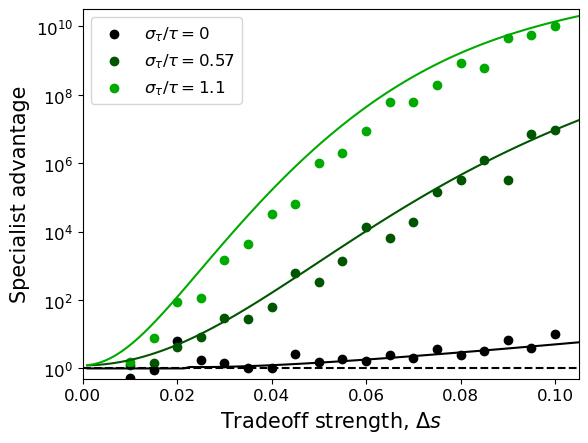

In [19]:
tau = period/2

xc = sg*2*np.log(N*sg)/np.log(sg/ug)
v = (2*sg**2 *np.log(N*sg))/(np.log(sg/ug)**2)

# Create a gradient of colors from black to green
colors = np.array(range(0,len(period_CV_vals)))/len(period_CV_vals)
colors = [(0, c, 0, 1) for c in colors]

s_tradeoff_range = np.linspace(0.001, 0.12, 100)

fig, ax = plt.subplots()

ax.axhline(y=1, color='black', linestyle='--')

# Plot the curves
for j in range(len(period_CV_vals)):

    ax.plot(s_tradeoff_vals, pfix_ratios[:, j], color=colors[j], linestyle='none')
    ax.scatter(s_tradeoff_vals, pfix_ratios[:, j], marker="o", color=colors[j],label=f'$\\sigma_\\tau/\\tau = {np.sqrt(2)*period_CV_vals[j]:.2g}$')

    pfix_gen = pfix_gen_rare(sg, xc, v)
    if j == 0:
        pfix_spec = pfix_spec_rare_deterministic(sg, s_tradeoff_range, tau, xc, v)
    else:
        pfix_spec = pfix_spec_rare_stochastic(sg, s_tradeoff_range, tau, xc, v, period_CV_vals[j] * period / np.sqrt(2), 100,calc_type=1) 
            
    ax.plot(s_tradeoff_range, np.maximum(1, pfix_spec/pfix_gen), color=colors[j])

# Set the labels and title
ax.set_xlabel('Tradeoff strength, $\Delta s$', fontsize=15)
ax.set_ylabel('Specialist advantage', fontsize=15)

ax.set_yscale('log')
ax.legend(fontsize=12)

ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xlim([0, 0.105])

ax.set_yticks([1, 1e2, 1e4, 1e6, 1e8, 1e10])
ax.set_ylim([0.5, 10**(10.5)])

#plt.savefig(r'Figures\3B_Stochastic_Long_Fixation.pdf', format='pdf')

# Show the plot
plt.show()

In [ ]:
# FIGURE 3C, rare specialist advantage in stochastic environment with short epochs

pfix_ratios = np.zeros((19,3))

sg = 0.02
ug = 3e-9
N = 1e20
period = 20
s_tradeoff_vals = [0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2]
period_CV_vals = [0, 0.4, 0.8]

for i in range(0,len(s_tradeoff_vals)):
    for j in range(0,len(period_CV_vals)):
        fname = 'Fig3_Data/N_' + str(N) + '_us_rare_ss_' + str(s_tradeoff_vals[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_' + str(period_CV_vals[j]) + '_small_output.pickle'

        if os.path.isfile(fname):
            with open(fname,'rb') as file:
                data = pickle.load(file)
        else:
            print(fname)
            continue

        pfix_gen = data['rate_gen']/(N*ug)
        pfix_spec = (np.array(data['fixations']) * np.array(data['pfix_adjustments'])).sum() / len(data['fixations'])

        pfix_ratios[i,j] = pfix_spec/pfix_gen

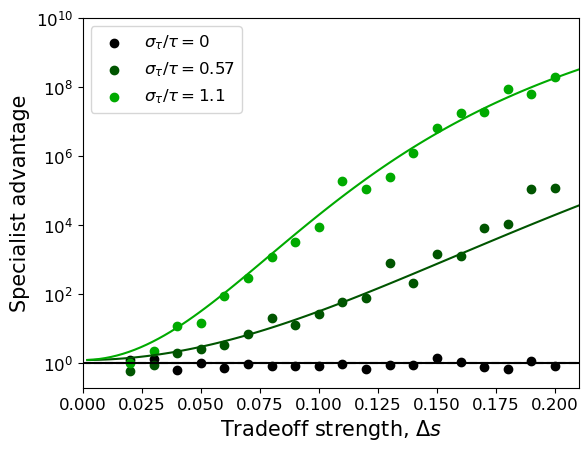

In [21]:
tau = period/2

xc = sg*2*np.log(N*sg)/np.log(sg/ug)
v = (2*sg**2 *np.log(N*sg))/(np.log(sg/ug)**2)

# Create a gradient of colors from black to green
colors = np.array(range(0,len(period_CV_vals)))/len(period_CV_vals)
colors = [(0, c, 0, 1) for c in colors]

s_tradeoff_range = np.linspace(0.002, 0.25, 100)

fig, ax = plt.subplots()

ax.axhline(y=1, color='black', linestyle='--')

# Plot the curves
for j in range(len(period_CV_vals)):
    ax.plot(s_tradeoff_vals, pfix_ratios[:, j], color=colors[j], linestyle='none')
    ax.scatter(s_tradeoff_vals, pfix_ratios[:, j], marker="o", color=colors[j],label = f'$\\sigma_\\tau/\\tau = {np.sqrt(2)*period_CV_vals[j]:.2g}$')
    
    pfix_gen = pfix_gen_rare(sg, xc, v)
    if j == 0:
        pfix_spec = pfix_spec_rare_deterministic(sg, s_tradeoff_range, tau, xc, v)
    else:
        pfix_spec = pfix_spec_rare_stochastic(sg, s_tradeoff_range, tau, xc, v, period_CV_vals[j] * period / np.sqrt(2), 100,calc_type=1) 
            
    ax.plot(s_tradeoff_range, np.maximum(1, pfix_spec/pfix_gen), color=colors[j])

# Set the labels and title
ax.set_xlabel('Tradeoff strength, $\Delta s$', fontsize=15)
ax.set_ylabel('Specialist advantage', fontsize=15)

ax.set_yscale('log')
ax.legend(fontsize=12)

ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xlim([0, 0.21])

ax.set_yticks([1, 1e2, 1e4, 1e6, 1e8, 1e10])

#plt.savefig(r'Figures\3C_Stochastic_Short_Fixation.pdf', format='pdf')

# Show the plot
plt.show()

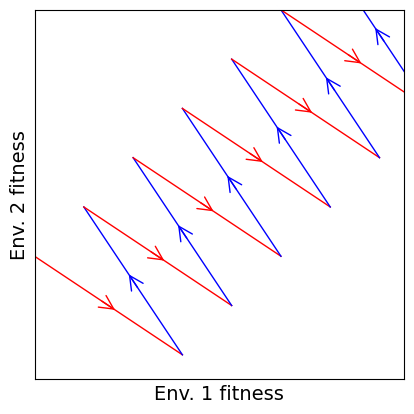

In [22]:
# FIGURE 4A, two-dimensional population mean fitness schematic

vpar = 0.001
vperp = 0.005
tau = 200

for i in range(0,12):
    ind_func = -1 if i % 2 == 0 else 1
    X0, X1 = tau*vpar*i, tau*vpar*(i+1)
    Y0, Y1 = ind_func*vperp*tau/2, -ind_func*vperp*tau/2

    x0, y0 = X0+Y0, X0-Y0
    x1, y1 = X1+Y1, X1-Y1

    color = 'red' if i % 2 == 0 else 'blue'
    plt.plot([x0,x1],[y0,y1], linewidth=1, color=color)

    xm, ym = (x0+x1)/2, (y0+y1)/2
    frac = 0.06
    plt.annotate('', xy=(xm+frac*(x1-x0), ym+frac*(y1-y0)), xytext=(xm-frac*(x1-x0), ym-frac*(y1-y0)),
                 arrowprops=dict(arrowstyle='->', color=color, lw=1, mutation_scale=25))

plt.xlabel('Env. 1 fitness', fontsize=14)
plt.ylabel('Env. 2 fitness', fontsize=14)

plt.xticks([])
plt.yticks([])

plt.xlim([-0.5,2.5]); plt.ylim([-0.5,2.5])

plt.gca().set_aspect('equal', adjustable='box')

#plt.savefig(r'Figures\4A_Background_Fitness.pdf', format='pdf')
plt.show()

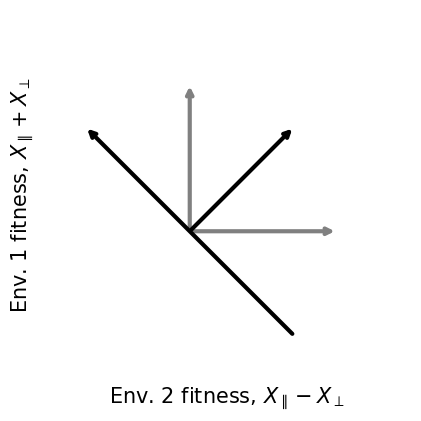

In [23]:
plt.annotate("", xytext=(0, 0), xy=(0, 1), arrowprops=dict(arrowstyle="->", linewidth=3, color='gray'))
plt.annotate("", xytext=(0, 0), xy=(1, 0), arrowprops=dict(arrowstyle="->", linewidth=3, color='gray'))

plt.annotate("", xytext=(0, 0), xy=(1/np.sqrt(2), 1/np.sqrt(2)), arrowprops=dict(arrowstyle="->", linewidth=3, color='black'))
plt.annotate("", xytext=(1/np.sqrt(2), -1/np.sqrt(2)), xy=(-1/np.sqrt(2), 1/np.sqrt(2)), arrowprops=dict(arrowstyle="->", linewidth=3, color='black'))

plt.xticks([])
plt.yticks([])
plt.xlabel('Env. 2 fitness, $X_\parallel - X_\perp$', fontsize=15)
plt.ylabel('Env. 1 fitness, $X_\parallel + X_\perp$', fontsize=15)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)

plt.axis('square')
plt.xlim([-1,1.5])
plt.ylim([-1,1.5])

# plt.savefig(r'Figures\4A_Rotated_Axes.pdf', format='pdf')
plt.show()


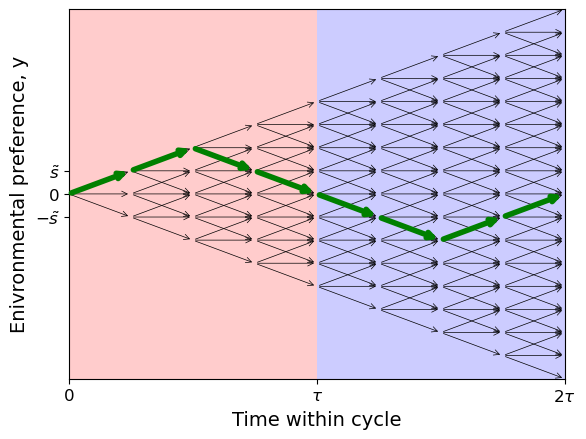

In [24]:
# FIGURE 4B, optimal path analysis

for i in range(0,8):
    for j in range(-i,i+1):
        plt.annotate("",xytext=(i, j),xy=(i+1, j+1),arrowprops=dict(arrowstyle="->", linewidth=0.5))
        plt.annotate("",xytext=(i, j),xy=(i+1, j-1),arrowprops=dict(arrowstyle="->", linewidth=0.5))
        plt.annotate("",xytext=(i, j),xy=(i+1, j),arrowprops=dict(arrowstyle="->", linewidth=0.5))

plt.annotate("", xytext=(0, 0), xy=(1, 1), arrowprops=dict(arrowstyle="->", linewidth=4, color='green'))
plt.annotate("", xytext=(1, 1), xy=(2, 2), arrowprops=dict(arrowstyle="->", linewidth=4, color='green'))
plt.annotate("", xytext=(2, 2), xy=(3, 1), arrowprops=dict(arrowstyle="->", linewidth=4, color='green'))
plt.annotate("", xytext=(3, 1), xy=(4, 0), arrowprops=dict(arrowstyle="->", linewidth=4, color='green'))
plt.annotate("", xytext=(4, 0), xy=(5, -1), arrowprops=dict(arrowstyle="->", linewidth=4, color='green'))
plt.annotate("", xytext=(5, -1), xy=(6, -2), arrowprops=dict(arrowstyle="->", linewidth=4, color='green'))
plt.annotate("", xytext=(6, -2), xy=(7, -1), arrowprops=dict(arrowstyle="->", linewidth=4, color='green'))
plt.annotate("", xytext=(7, -1), xy=(8, 0), arrowprops=dict(arrowstyle="->", linewidth=4, color='green'))


plt.xlabel('Time within cycle',fontsize=14)
plt.ylabel('Enivronmental preference, y',fontsize=14)

plt.axvspan(0,4, facecolor='red', alpha=0.2)
plt.axvspan(4,8, facecolor='blue', alpha=0.2)

plt.xlim([0,8])
plt.ylim([-8,8])
plt.xticks([0,4,8], ['0', r'$\tau$', r'$2\tau$'], fontsize=12)
plt.yticks([-1,0,1],[r'$-\tilde{s}$', '0', r'$\tilde{s}$'], fontsize=12)

#plt.savefig(r'Figures\4A_Optimal_Path_Schematic.pdf', format='pdf')
plt.show()



In [ ]:
# Load in preprocessed data, combined across many runs with the same parameters

sg = 0.02
ug = 3e-9
N = 1e20
period = 400
s_tradeoff = 0.05
us = 3e-9

fname = 'Highly_Sampled_Data/Combined_Data_N_' + str(N) + '_us_' + str(us) + '_ss_' + str(s_tradeoff) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_0.pickle'

with open(fname, 'rb') as file:
    data = pickle.load(file)

all_fixations = data['all_fixations']
all_adjustments = data['all_adjustments']
all_fix_starts = data['all_fix_starts']
all_bgs = data['all_bgs']
all_muttypes = data['all_muttypes']
bias = data['bias']
bias_std = data['bias_std']

In [26]:
mod_starts = np.mod(all_fix_starts,period)
bg_bias = np.array([bg[1]- bg[2] for bg in all_bgs])

successful = all_fixations == 1
time_bins = np.linspace(0,period,50)
n_bins = len(time_bins) - 1
 
avg_mut = np.zeros(n_bins)
avg_time = np.zeros(n_bins)
 
for i in range(n_bins):
    mask = np.logical_and(successful, np.logical_and(mod_starts >= time_bins[i], mod_starts < time_bins[i+1]))
    w = all_adjustments[mask]
    w[all_muttypes[mask] == 0] *= 2 # Correct for weighting of generalist mutations
    wsum = np.sum(w)
 
    bg_base = bg_bias[mask] + bias[mod_starts[mask].astype(int)]
    bg_plus_mut = all_muttypes[mask] + bg_base
 
    avg_mut[i] = np.sum(bg_plus_mut*w)/wsum
    avg_time[i] = np.sum(np.mod(all_fix_starts[mask], period)*w)/wsum


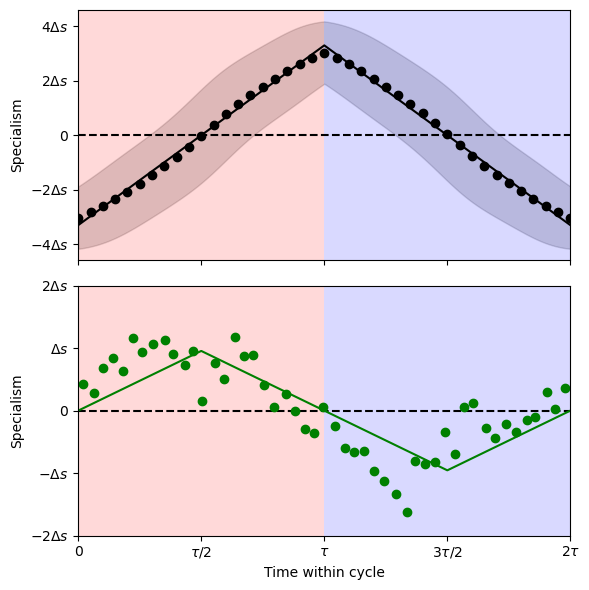

In [27]:
def triangle_wave(t, period):
    """Zero-mean triangle wave, unit slope, peak at period/4 and trough at 3*period/4."""
    t = np.mod(t, period)
    return np.where(t <= period/4, t, np.where(t <= 3*period/4, period/2 - t, t - period))

tau = period/2
spacing = 10

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6, 6))

nn = np.arange(len(bias))
bias_c = s_tradeoff*(bias - np.mean(bias))
mut_c = s_tradeoff*(avg_mut - np.mean(bias))

g = triangle_wave(avg_time, period)
slope_mut = np.sum(g*mut_c)/np.sum(g**2)
t_fit_mut = np.array([0, period/4, 3*period/4, period])

h = triangle_wave(nn - period/4, period)
slope_bias = np.sum(h*bias_c)/np.sum(h**2)
t_fit_bias = np.array([0, period/2, period])

ax1.plot([0, period], [0, 0], color='black', linestyle='--')
ax1.plot(nn[::spacing], bias_c[::spacing], label='Population mean', color='black', marker='o', linestyle='none')
ax1.fill_between(nn, s_tradeoff*(bias - bias_std - np.mean(bias)), s_tradeoff*(bias + bias_std - np.mean(bias)), color='black', alpha=0.15)
ax1.plot(t_fit_bias, slope_bias*triangle_wave(t_fit_bias - period/4, period), color='black', linestyle='-')

ax2.plot([0, period], [0, 0], color='black', linestyle='--')
ax2.plot(avg_time, mut_c, label='Successful lineages', color='green', marker='o', linestyle='none')
ax2.plot(t_fit_mut, slope_mut*triangle_wave(t_fit_mut, period), color='green', linestyle='-')

for ax in (ax1, ax2):
    ax.axvspan(0, period/2, facecolor='red', alpha=0.15)
    ax.axvspan(period/2, period, facecolor='blue', alpha=0.15)
    ax.set_xlim([0, period])
    ax.set_ylabel('Specialism')

ax1.set_yticks([-4*s_tradeoff, -2*s_tradeoff, 0, 2*s_tradeoff, 4*s_tradeoff])
ax1.set_yticklabels(['$-4\Delta s$', '$-2\Delta s$', '$0$', '$2\Delta s$', '$4\Delta s$'])

ax2.set_yticks([-2*s_tradeoff, -s_tradeoff, 0, s_tradeoff, 2*s_tradeoff])
ax2.set_yticklabels(['$-2\Delta s$', '$-\Delta s$', '$0$', '$\Delta s$', '$2\Delta s$'])

ax2.set_xticks([0, tau/2, tau, 3*tau/2, 2*tau])
ax2.set_xticklabels(['0', r'$\tau/2$', r'$\tau$', r'$3\tau/2$', r'2$\tau$'])
ax2.set_xlabel('Time within cycle')

plt.tight_layout()

#plt.savefig(r'Figures\4B_Optimal_Path.pdf', format='pdf')
plt.show()

In [ ]:
# FIGURE 4C, specialist advantage in frequent-specialist regime

# Longer epochs

sg = 0.02
ug = 3e-9
us = 3e-9
N = 1e20
period = 250
s_tradeoff_vals1 = [0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05, 0.055, 0.06, 0.065, 0.07, 0.075, 0.08, 0.085, 0.09, 0.095, 0.1]
period_CV_vals1 = [0, 0.4, 0.8]
vpar_est1 = np.zeros((len(s_tradeoff_vals1),len(period_CV_vals1)))

pfix_ratios1 = np.zeros((len(s_tradeoff_vals1),3))

for i in range(0,len(s_tradeoff_vals1)):
    for j in range(0,len(period_CV_vals1)):
        if j > 0:
            fname = 'Fig4C-5_Data/N_' + str(N) + '_us_' + str(us) + '_ss_' + str(s_tradeoff_vals1[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_' + str(period_CV_vals1[j]) + '.pickle'
        else:
            fname = 'Fig4C-5_Data/N_' + str(N) + '_us_' + str(us) + '_ss_' + str(s_tradeoff_vals1[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_' + str(period_CV_vals1[j]) + '_with_extra_info.pickle'
        if os.path.isfile(fname):
            with open(fname,'rb') as file:
                data = pickle.load(file)
        else:
            print(fname)
            continue

        times = np.array(data['times'])
        mut_freqs1 = np.array(data['mut_freqs1'])
        mut_freqs2 = np.array(data['mut_freqs2'])
        mut_freqs3 = np.array(data['mut_freqs3'])

        pfix_spec = np.polyfit(times[100:], mut_freqs2[100:] + mut_freqs3[100:], 1)[0] / (N * us)
        pfix_gen = np.polyfit(times[100:], mut_freqs1[100:], 1)[0] / (N * ug)

        vpar_est1[i,j] = (pfix_spec*us + pfix_gen*ug)*sg*N
            
        pfix_ratios1[i,j] = pfix_spec/pfix_gen

    xc_est1 = vpar_est1/sg*np.log(sg/ug)+sg/2

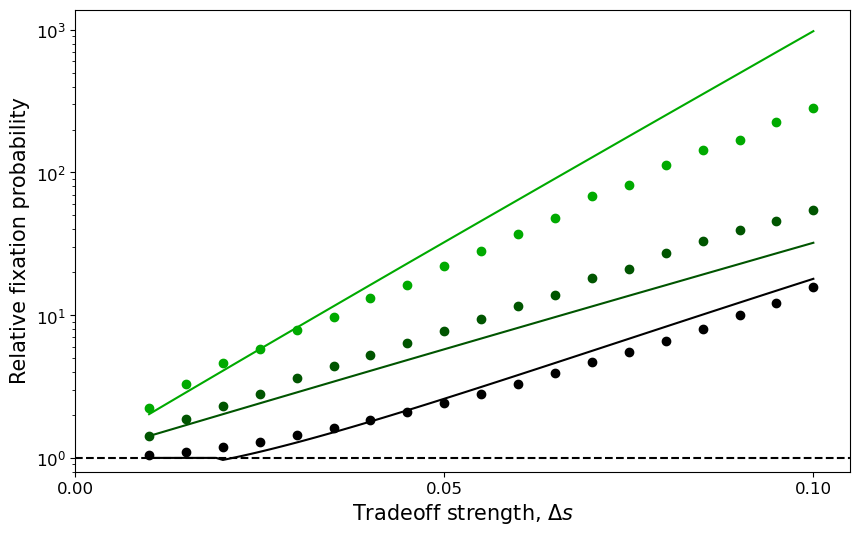

In [29]:
tau = period/2

pfix_ratio_est1 = np.zeros((len(s_tradeoff_vals1), len(period_CV_vals1)-1))
for i in range(0,len(s_tradeoff_vals1)):
    for j in range(0,len(period_CV_vals1)-1):
        pfix_ratio_est1[i,j] = pfix_ratio_frequent_stochastic_simple(sg, s_tradeoff_vals1[i], tau, xc_est1[i,j+1], vpar_est1[i,j+1], period_CV_vals1[j+1]*period/np.sqrt(2))

s_tradeoff_range = np.linspace(s_tradeoff_vals1[0], s_tradeoff_vals1[-1], 100)

vpar0 = 2*sg**2*np.log(N*sg)/np.log(sg/ug)**2

# Define the colors for the plots
colors = [(0, i/len(period_CV_vals1), 0) for i in range(len(period_CV_vals1))]

# Create the plot
plt.figure(figsize=(10, 6))

plt.plot([0,0.205],[1,1],color='black',linestyle='--')

for j in range(len(period_CV_vals1)):
    plt.plot(s_tradeoff_vals1, pfix_ratios1[:, j], color=colors[j], marker = 'o',linestyle='None')

    if j == 0:
        plt.plot(s_tradeoff_range, np.exp(pfix_ratio_frequent_deterministic(sg, np.array(s_tradeoff_range), tau, vpar0)), color=colors[j], label=f'$\\sigma_\\tau/\\tau = {np.sqrt(2)*period_CV_vals1[j]:.2g}$')
    else:
        plt.plot(s_tradeoff_vals1,pfix_ratio_est1[:,j-1], color=colors[j], label=f'$\\sigma_\\tau/\\tau = {np.sqrt(2)*period_CV_vals1[j]:.2g}$')

# Set the labels and title
plt.xlabel('Tradeoff strength, $\Delta s$', fontsize=15)
plt.ylabel('Relative fixation probability', fontsize=15)
plt.yscale('log')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim([0, 0.105])
plt.xticks([0,0.05,0.1])

plt.ylim(bottom = 0.8)

#plt.savefig(r'Figures\4C_Pfix_Ratio_Long.pdf', format='pdf')

plt.show()

In [ ]:
# Shorter epochs

pfix_ratios2 = np.zeros((20,3))

sg = 0.02
ug = 3e-9
us = 3e-9
N = 1e20
period = 50
s_tradeoff_vals2 = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2]
period_CV_vals2 = [0, 0.4, 0.8]
vpar_est2 = np.zeros((20,len(period_CV_vals2)))

for i in range(0,len(s_tradeoff_vals2)):
    for j in range(0,len(period_CV_vals2)):
        if j > 0:
            fname = 'Fig4C-5_Data/N_' + str(N) + '_us_' + str(us) + '_ss_' + str(s_tradeoff_vals2[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_' + str(period_CV_vals2[j]) + '.pickle'
        else:
            fname = 'Fig4C-5_Data/N_' + str(N) + '_us_' + str(us) + '_ss_' + str(s_tradeoff_vals2[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_' + str(period_CV_vals2[j]) + '_with_extra_info.pickle'
        if os.path.isfile(fname):
            with open(fname,'rb') as file:
                data = pickle.load(file)
        else:
            print(fname)
            continue

        times = np.array(data['times'])
        mut_freqs1 = np.array(data['mut_freqs1'])
        mut_freqs2 = np.array(data['mut_freqs2'])
        mut_freqs3 = np.array(data['mut_freqs3'])

        pfix_spec = np.polyfit(times[100:], mut_freqs2[100:] + mut_freqs3[100:], 1)[0] / (N * us)
        pfix_gen = np.polyfit(times[100:], mut_freqs1[100:], 1)[0] / (N * ug)

        vpar_est2[i,j] = (pfix_spec*us + pfix_gen*ug)*sg*N
            
        pfix_ratios2[i,j] = pfix_spec/pfix_gen

    xc_est2 = vpar_est2/sg*np.log(sg/ug)+sg/2


C:\Users\johnd\AppData\Local\Temp\ipykernel_28960\1160754885.py:38: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(bottom = 0)


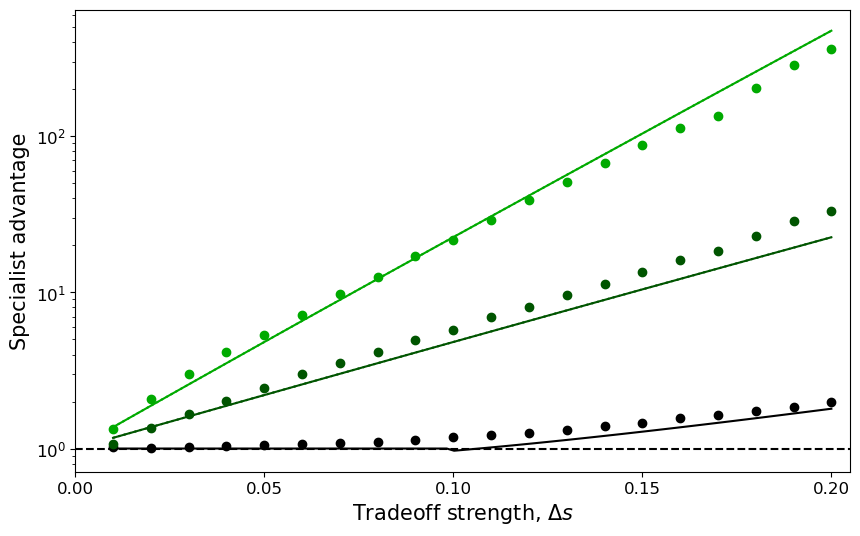

In [31]:
tau = period/2

pfix_ratio_est2 = np.zeros((len(s_tradeoff_vals2), len(period_CV_vals2)-1))

for i in range(0,len(s_tradeoff_vals2)):
    for j in range(0,len(period_CV_vals2)-1):
        pfix_ratio_est2[i,j] = pfix_ratio_frequent_stochastic_simple(sg, s_tradeoff_vals2[i], tau, xc_est2[i,j+1], vpar_est2[i,j+1], period_CV_vals2[j+1]*period/np.sqrt(2))

vpar0 = 2*sg**2*np.log(N*sg)/np.log(sg/ug)**2

# Define the colors for the plots
colors = [(0, i/len(period_CV_vals2), 0) for i in range(len(period_CV_vals2))]

# Create the plot
plt.figure(figsize=(10, 6))

s_tradeoff_range = np.linspace(0.01, 0.2, 100)
plt.plot([0,0.205],[1,1],color='black',linestyle='--')

for j in range(len(period_CV_vals2)):
    plt.plot(s_tradeoff_vals2, pfix_ratios2[:, j], color=colors[j], marker = 'o',linestyle='None')

    if j == 0:
        plt.plot(s_tradeoff_range, np.exp(pfix_ratio_frequent_deterministic(sg, np.array(s_tradeoff_range), tau, vpar0)), color=colors[j], label=f'$\\sigma_\\tau/\\tau = {np.sqrt(2)*period_CV_vals2[j]:.2g}$')
    else:
        plt.plot(s_tradeoff_vals2,pfix_ratio_est2[:,j-1], color=colors[j], label=f'$\\sigma_\\tau/\\tau = {np.sqrt(2)*period_CV_vals2[j]:.2g}$')
        plt.plot(s_tradeoff_vals2,pfix_ratio_est2[:,j-1], color=colors[j],linestyle=':')

# Set the labels and title
plt.xlabel('Tradeoff strength, $\Delta s$', fontsize=15)
plt.ylabel('Specialist advantage', fontsize=15)
plt.yscale('log')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim([0, 0.205])
plt.xticks([0,0.05,0.1,0.15,0.2])

plt.ylim(bottom = 0)

#plt.savefig(r'Figures\4C_Pfix_Ratio_Short.pdf', format='pdf')

plt.show()

In [ ]:
# FIGURE 5, adaptation rate

s_tradeoff_vals = np.array([0.03, 0.06, 0.09])
s_tradeoff_vals2 = np.array([0.05, 0.1, 0.2])
sg_vals = np.array([0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04])
period_CV_vals = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

vpar_est = np.zeros((len(s_tradeoff_vals), len(sg_vals)))
vpar_est2 = np.zeros((len(s_tradeoff_vals), len(period_CV_vals)))
vpar_est3 = np.zeros((len(s_tradeoff_vals2), len(period_CV_vals)))

ug = 3e-9
us = 3e-9
N = 1e20
period = 400

for i in range(len(s_tradeoff_vals)):
    for j in range(len(sg_vals)):
        fname = 'Fig4C-5_Data/N_' + str(N) + '_us_' + str(us) + '_ss_' + str(s_tradeoff_vals[i]) + '_ug_' + str(ug) + '_sg_' + str(sg_vals[j]) + '_tau_' + str(period) + '_dtau_0.pickle'
        if os.path.isfile(fname):
            with open(fname,'rb') as file:
                data = pickle.load(file)
        else:
            print(fname)
            continue

        vpar_est[i,j] = sg_vals[j]*np.polyfit(data['times'][100:],np.array(data['mut_freqs1'])[100:]+np.array(data['mut_freqs2'])[100:]+np.array(data['mut_freqs3'])[100:],1)[0]

sg = 0.02
ug = 3e-9
us = 3e-9
N = 1e20
period = 250

for i in range(0,len(s_tradeoff_vals)):
    for j in range(0,len(period_CV_vals)):
        fname = 'Fig4C-5_Data/N_' + str(N) + '_us_' + str(us) + '_ss_' + str(s_tradeoff_vals[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_' + str(period_CV_vals[j]) + '_with_extra_info.pickle'
        if os.path.isfile(fname):
            with open(fname,'rb') as file:
                data = pickle.load(file)
        else:
            print(fname)
            continue

        times = np.array(data['times'])
        mut_freqs1 = np.array(data['mut_freqs1'])
        mut_freqs2 = np.array(data['mut_freqs2'])
        mut_freqs3 = np.array(data['mut_freqs3'])

        vpar_est2[i,j] = sg*np.polyfit(times[100:], mut_freqs1[100:] + mut_freqs2[100:] + mut_freqs3[100:], 1)[0]


sg = 0.02
ug = 3e-9
us = 3e-9
N = 1e20
period = 50

for i in range(0,len(s_tradeoff_vals2)):
    for j in range(0,len(period_CV_vals)):
        fname = 'Fig4C-5_Data/N_' + str(N) + '_us_' + str(us) + '_ss_' + str(s_tradeoff_vals2[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_' + str(period_CV_vals[j]) + '_with_extra_info.pickle'
        if os.path.isfile(fname):
            with open(fname,'rb') as file:
                data = pickle.load(file)
        else:
            print(fname)
            continue

        times = np.array(data['times'])
        mut_freqs1 = np.array(data['mut_freqs1'])
        mut_freqs2 = np.array(data['mut_freqs2'])
        mut_freqs3 = np.array(data['mut_freqs3'])

        vpar_est3[i,j] = sg*np.polyfit(times[100:], mut_freqs1[100:] + mut_freqs2[100:] + mut_freqs3[100:], 1)[0]

In [33]:
sg_range = np.linspace(sg_vals[0], sg_vals[-1], 100)
period_CV_range = np.linspace(period_CV_vals[0], period_CV_vals[-1], 100)

vpar_pred1 = np.zeros((vpar_est.shape[0], len(sg_range)))
vpar_pred2 = np.zeros((vpar_est2.shape[0], len(period_CV_range)))
vpar_pred3 = np.zeros((vpar_est3.shape[0], len(period_CV_range)))

period = 400
tau = period/2
for i in range(len(s_tradeoff_vals)):
    for j in range(len(sg_range)):
        vpar_pred1[i, j], _ = v_est_deterministic(sg_range[j], s_tradeoff_vals[i], tau, ug, N)

period = 250
tau = period/2
for i in range(len(s_tradeoff_vals)):
    for j in range(len(period_CV_range)):
        if j == 0:
            vpar_pred2[i,j], _ = v_est_deterministic(sg, s_tradeoff_vals[i], tau, ug, N)
        else:
            vpar_pred2[i,j], _ = v_est_stochastic(sg, s_tradeoff_vals[i], tau, period_CV_range[j]*period/np.sqrt(2), ug, N)

period = 50
tau = period/2
for i in range(len(s_tradeoff_vals2)):
    for j in range(len(period_CV_range)):
        if j == 0:
            vpar_pred3[i,j], _ = v_est_deterministic(sg, s_tradeoff_vals2[i], tau, ug, N)
        else:
            vpar_pred3[i,j], _ = v_est_stochastic(sg, s_tradeoff_vals2[i], tau, period_CV_range[j]*period/np.sqrt(2), ug, N)

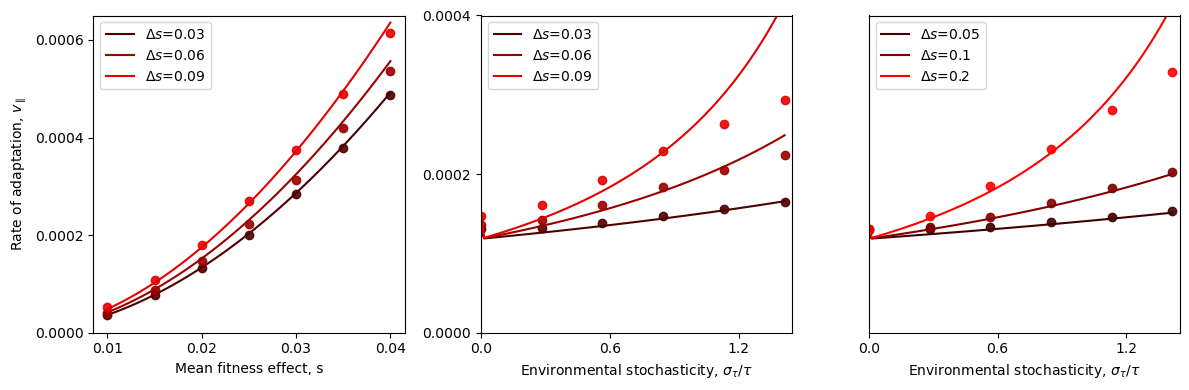

In [34]:
period_CV_plot = np.array(period_CV_vals)

colors = [(s_tradeoff/0.1, 0, 0) for s_tradeoff in s_tradeoff_vals]
colors2 = [(s_tradeoff/0.2, 0, 0) for s_tradeoff in s_tradeoff_vals2]

fig, axs = plt.subplots(1, 3, figsize=(12, 4))

# left: vpar vs sg_vals
for i, (s_tradeoff, col) in enumerate(zip(s_tradeoff_vals, colors)):
    axs[0].plot(sg_vals, vpar_est[i, :], marker='o', linestyle='None', color=col, alpha=0.9)
    axs[0].plot(sg_range, vpar_pred1[i, :], color=col, linewidth=1.5, label=f'$\Delta s$={s_tradeoff}')

axs[0].set_xlabel('Mean fitness effect, s')
axs[0].set_ylabel('Rate of adaptation, $v_\parallel$')
axs[0].legend()
axs[0].set_ylim([0,0.00065])
axs[0].set_yticks([0,0.0002,0.0004,0.0006])
axs[0].set_xticks([0.01,0.02,0.03,0.04])

for i, (s_tradeoff, col) in enumerate(zip(s_tradeoff_vals, colors)):
    axs[1].plot(period_CV_plot*np.sqrt(2), vpar_est2[i, :], marker='o', linestyle='None', color=col, alpha=0.9)
    axs[1].plot(period_CV_range*np.sqrt(2), vpar_pred2[i, :], color=col, linewidth=1.5, label=f'$\Delta s$={s_tradeoff}')

axs[1].set_xlabel(r'Environmental stochasticity, $\sigma_\tau/\tau$')
axs[1].set_ylim([0,0.0004])
axs[1].set_xlim([0,1.45])
axs[1].set_yticks([0,0.0002,0.0004])
axs[1].set_xticks([0,0.6,1.2])
axs[1].legend()


axs[2].set_ylabel('')
axs[2].set_yticks([])

for i, (s_tradeoff, col) in enumerate(zip(s_tradeoff_vals2, colors2)):
    axs[2].plot(period_CV_plot*np.sqrt(2), vpar_est3[i, :], marker='o', linestyle='None', color=col, alpha=0.9)
    axs[2].plot(period_CV_range*np.sqrt(2), vpar_pred3[i, :], color=col, linewidth=1.5, label=f'$\Delta s$={s_tradeoff}')

axs[2].set_xlabel(r'Environmental stochasticity, $\sigma_\tau/\tau$')
axs[2].set_ylim([0,0.0004])
axs[2].set_xlim([0,1.45])
axs[2].set_xticks([0,0.6,1.2])
axs[2].legend()

plt.tight_layout()
#plt.savefig(r'Figures\5_Adaptation_Rate.pdf', format='pdf')
plt.show()

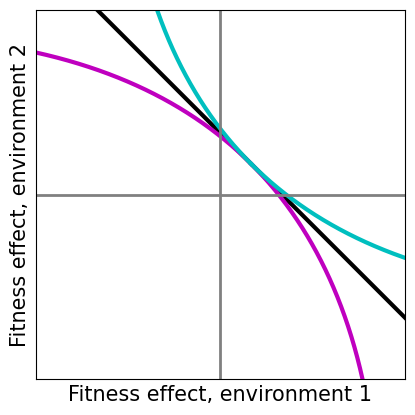

In [35]:
# FIGURE 6A, isocline schematic

sg = 0.02

plt.plot([-0.12+sg,0.12+sg],[0.12+sg,-0.12+sg], color='black',linewidth=3, label='Average environment')

s_tradeoff_theory = np.linspace(0,0.15,1000)
delta_x_theory = 3*(s_tradeoff_theory**2)

x_theory = sg - delta_x_theory - s_tradeoff_theory
y_theory = sg - delta_x_theory + s_tradeoff_theory
plt.plot(x_theory, y_theory, color=[0.75,0,0.75], linewidth=3, label=r'Tradeoffs favored')
x_theory = sg - delta_x_theory + s_tradeoff_theory
y_theory = sg - delta_x_theory - s_tradeoff_theory
plt.plot(x_theory, y_theory, color=[0.75,0,0.75], linewidth=3)

delta_x_theory = -3*(s_tradeoff_theory**2)

x_theory = sg - delta_x_theory - s_tradeoff_theory
y_theory = sg - delta_x_theory + s_tradeoff_theory
plt.plot(x_theory, y_theory, color=[0,0.75,0.75], linewidth=3, label=r'Tradeoffs disfavored')
x_theory = sg - delta_x_theory + s_tradeoff_theory
y_theory = sg - delta_x_theory - s_tradeoff_theory
plt.plot(x_theory, y_theory, color=[0,0.75,0.75], linewidth=3)

plt.plot([-0.12,0.12],[0,0], color='gray', linewidth=2)
plt.plot([0,0],[-0.12,0.12], color='gray', linewidth=2)


plt.xlabel('Fitness effect, environment 1',fontsize=15)
plt.ylabel('Fitness effect, environment 2',fontsize=15)
plt.axis('square')
plt.xlim([-0.12, 0.12])
plt.ylim([-0.12, 0.12])
plt.xticks([],fontsize=12)
plt.yticks([],fontsize=12)

#plt.savefig(r'Figures\6A_Isocline_Schematic.pdf', format='pdf')
plt.show()

In [ ]:
# FIGURE 6B, rare specialist isoclines

pfix_ratios = np.zeros((10,13))

sg = 0.02
ug = 3e-9
N = 1e20
period = 400
s_tradeoff_vals = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]
ds0_vals = [-0.01, -0.009, -0.008, -0.007, -0.006, -0.005, -0.004, -0.003, -0.002, -0.001, 0, 0.001, 0.002]

for i in range(0,len(s_tradeoff_vals)):
    for j in range(0,len(ds0_vals)):
        fname = 'Fig6_Data/N_' + str(N) + '_us_rare_ss_' + str(s_tradeoff_vals[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_0_small_output_ds0_' + str(ds0_vals[j]) + '.pickle'

        if os.path.isfile(fname):
            with open(fname,'rb') as file:
                data = pickle.load(file)
        else:
            print(fname)
            continue

        pfix_gen = data['rate_gen']/(N*ug)
        pfix_spec = (np.array(data['fixations']) * np.array(data['pfix_adjustments'])).sum() / len(data['fixations'])

        pfix_ratios[i,j] = pfix_spec/pfix_gen

ds0_eff = np.zeros(10)

for j in range(0,10):
    pfix_ratio = pfix_ratios[j,:]
    filt = np.logical_and(np.log(pfix_ratio) > -10, np.log(pfix_ratio) < 10)

    coeffs = np.polyfit(np.array(ds0_vals)[filt], np.log(pfix_ratio[filt]), 1)
    ds0_eff[j] = -coeffs[1] / coeffs[0]

iso1A = [sg]
iso2A = [sg]

for j in range(0,10):
    iso1A.append(sg+ds0_eff[j] + s_tradeoff_vals[j])
    iso1A.append(sg+ds0_eff[j] - s_tradeoff_vals[j])
    iso2A.append(sg+ds0_eff[j] - s_tradeoff_vals[j])
    iso2A.append(sg+ds0_eff[j] + s_tradeoff_vals[j])

In [ ]:
pfix_ratios = np.zeros((10,13))

sg = 0.02
ug = 3e-9
N = 1e20
period = 400
s_tradeoff_vals = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]
ds0_vals = [-0.05, -0.045, -0.04, -0.035, -0.03, -0.025, -0.02, -0.015, -0.01, -0.005, 0, 0.002, 0.004]

for i in range(0,len(s_tradeoff_vals)):
    for j in range(0,len(ds0_vals)):
        fname = 'Fig6_Data/N_' + str(N) + '_us_rare_ss_' + str(s_tradeoff_vals[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_0.4_small_output_ds0_' + str(ds0_vals[j]) + '.pickle'

        if os.path.isfile(fname):
            with open(fname,'rb') as file:
                data = pickle.load(file)
        else:
            print(fname)
            continue

        pfix_gen = data['rate_gen']/(N*ug)
        pfix_spec = (np.array(data['fixations']) * np.array(data['pfix_adjustments'])).sum() / len(data['fixations'])

        pfix_ratios[i,j] = pfix_spec/pfix_gen

ds0_eff = np.zeros(10)

for j in range(0,10):
    pfix_ratio = pfix_ratios[j,:]
    filt = np.logical_and(np.log(pfix_ratio) > -10, np.log(pfix_ratio) < 10)

    coeffs = np.polyfit(np.array(ds0_vals)[filt], np.log(pfix_ratio[filt]), 1)
    ds0_eff[j] = -coeffs[1] / coeffs[0]

iso1B = [sg]
iso2B = [sg]

for j in range(0,10):
    iso1B.append(sg+ds0_eff[j] + s_tradeoff_vals[j])
    iso1B.append(sg+ds0_eff[j] - s_tradeoff_vals[j])
    iso2B.append(sg+ds0_eff[j] - s_tradeoff_vals[j])
    iso2B.append(sg+ds0_eff[j] + s_tradeoff_vals[j])

C:\Users\johnd\AppData\Local\Temp\ipykernel_28960\287201286.py:30: RuntimeWarning: divide by zero encountered in log
  filt = np.logical_and(np.log(pfix_ratio) > -10, np.log(pfix_ratio) < 10)


In [ ]:
pfix_ratios = np.zeros((10,22))

sg = 0.02
ug = 3e-9
N = 1e20
period = 400
s_tradeoff_vals = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]
ds0_vals = [-0.1, -0.09, -0.085, -0.08, -0.075, -0.07, -0.065, -0.06, -0.055, -0.05, -0.045, -0.04, -0.035, -0.03, -0.025, -0.02, -0.015, -0.01, -0.005, 0, 0.002, 0.004]

for i in range(0,len(s_tradeoff_vals)):
    for j in range(0,len(ds0_vals)):
        fname = 'Fig6_Data/N_' + str(N) + '_us_rare_ss_' + str(s_tradeoff_vals[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_0.8_small_output_ds0_' + str(ds0_vals[j]) + '.pickle'

        if os.path.isfile(fname):
            with open(fname,'rb') as file:
                data = pickle.load(file)
        else:
            print(fname)
            continue

        pfix_gen = data['rate_gen']/(N*ug)
        pfix_spec = (np.array(data['fixations']) * np.array(data['pfix_adjustments'])).sum() / len(data['fixations'])

        pfix_ratios[i,j] = pfix_spec/pfix_gen

ds0_eff = np.zeros(10)

for j in range(0,10):
    pfix_ratio = pfix_ratios[j,:]
    filt = np.logical_and(np.log(pfix_ratio) > -10, np.log(pfix_ratio) < 10)

    coeffs = np.polyfit(np.array(ds0_vals)[filt], np.log(pfix_ratio[filt]), 1)
    ds0_eff[j] = -coeffs[1] / coeffs[0]

iso1C = [sg]
iso2C = [sg]

for j in range(0,10):
    iso1C.append(sg+ds0_eff[j] + s_tradeoff_vals[j])
    iso1C.append(sg+ds0_eff[j] - s_tradeoff_vals[j])
    iso2C.append(sg+ds0_eff[j] - s_tradeoff_vals[j])
    iso2C.append(sg+ds0_eff[j] + s_tradeoff_vals[j])

C:\Users\johnd\AppData\Local\Temp\ipykernel_28960\1667453820.py:30: RuntimeWarning: divide by zero encountered in log
  filt = np.logical_and(np.log(pfix_ratio) > -10, np.log(pfix_ratio) < 10)


C:\Users\johnd\AppData\Local\Temp\ipykernel_28960\2529572078.py:13: RuntimeWarning: divide by zero encountered in divide
  pfix_spec = xc*np.sqrt(2*v/np.pi)/sg * np.exp(-(xc-sg -s_tradeoff*v*tau/(2*xc))**2/(2*v)) / (s_tradeoff*tau)


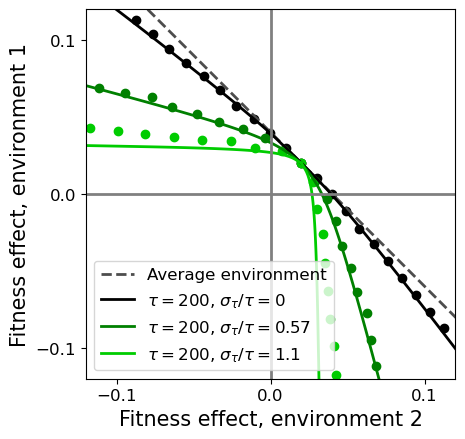

In [39]:
def sbar_rare_deterministic(sg, s_tradeoff, tau, xc, v):
    target = pfix_gen_rare(sg, xc, v)
    f = lambda sb: pfix_spec_rare_deterministic(sb, np.array([s_tradeoff]), tau, xc, v) - target
    return newton(f, sg)[0]

def sbar_rare_stochastic(sg, s_tradeoff, tau, xc, v, sigma_tau):
    target = np.log(pfix_gen_rare(sg, xc, v))
    f = lambda sb: np.log(pfix_spec_rare_stochastic(sb, np.array([s_tradeoff]), tau, xc, v, sigma_tau, c=3))[0] - target
    return newton(f, sg)

sg = 0.02
ug = 3e-9
N = 1e20
period = 400
tau = period/2
v = 2*sg**2*np.log(N*sg)/np.log(sg/ug)**2
xc = 2*sg*np.log(N*sg)/np.log(sg/ug)

plt.plot([-0.12+sg,0.12+sg],[0.12+sg,-0.12+sg], color=[0.3,0.3,0.3], linestyle = '--',linewidth=2, label='Average environment')

s_tradeoff_theory = np.linspace(0,0.15,100)

# Deterministic environment

sbar_theory = np.zeros_like(s_tradeoff_theory)
for i in range(len(s_tradeoff_theory)):
    sbar_theory[i] = sbar_rare_deterministic(sg, s_tradeoff_theory[i], tau, xc, v)

x_theory = sbar_theory - s_tradeoff_theory
y_theory = sbar_theory + s_tradeoff_theory
plt.plot(x_theory, y_theory, color='black', linewidth=2, label=r'$\tau = 200$, $\sigma_\tau/\tau = 0$')
x_theory = sbar_theory + s_tradeoff_theory
y_theory = sbar_theory - s_tradeoff_theory
plt.plot(x_theory, y_theory, color='black', linewidth=2)

# Stochastic environment
sbar_theory = sg * np.ones_like(s_tradeoff_theory)

n_fail = len(s_tradeoff_theory)
for i in range(1, len(s_tradeoff_theory)):
    try:
        sbar_theory[i] = sbar_rare_stochastic(sg, s_tradeoff_theory[i], tau, xc, v, 0.4*period/np.sqrt(2))
    except (ValueError, RuntimeError, FloatingPointError):
        n_fail = i
        break

# Linearly extrapolate sbar to region where integral approximation fails
if n_fail < len(s_tradeoff_theory):
    n_fit = 5
    m, b = np.polyfit(s_tradeoff_theory[n_fail-n_fit:n_fail], sbar_theory[n_fail-n_fit:n_fail], 1)
    sbar_theory[n_fail:] = m*s_tradeoff_theory[n_fail:] + b

x_theory = sbar_theory - s_tradeoff_theory
y_theory = sbar_theory + s_tradeoff_theory
plt.plot(x_theory, y_theory, color=[0,0.5,0], linewidth=2, label=r'$\tau = 200$, $\sigma_\tau/\tau = 0.57$')
x_theory = sbar_theory + s_tradeoff_theory
y_theory = sbar_theory - s_tradeoff_theory
plt.plot(x_theory, y_theory, color=[0,0.5,0], linewidth=2)

# Stochastic environment 2
sbar_theory = sg * np.ones_like(s_tradeoff_theory)

n_fail = len(s_tradeoff_theory)
for i in range(1, len(s_tradeoff_theory)):
    try:
        sbar_theory[i] = sbar_rare_stochastic(sg, s_tradeoff_theory[i], tau, xc, v, 0.8*period/np.sqrt(2))
    except (ValueError, RuntimeError, FloatingPointError):
        n_fail = i
        break

if n_fail < len(s_tradeoff_theory):
    n_fit = 5
    m, b = np.polyfit(s_tradeoff_theory[n_fail-n_fit:n_fail], sbar_theory[n_fail-n_fit:n_fail], 1)
    sbar_theory[n_fail:] = m*s_tradeoff_theory[n_fail:] + b

x_theory = sbar_theory - s_tradeoff_theory
y_theory = sbar_theory + s_tradeoff_theory
plt.plot(x_theory, y_theory, color=[0,0.8,0], linewidth=2, label=r'$\tau = 200$, $\sigma_\tau/\tau = 1.1$')
x_theory = sbar_theory + s_tradeoff_theory
y_theory = sbar_theory - s_tradeoff_theory
plt.plot(x_theory, y_theory, color=[0,0.8,0], linewidth=2)

plt.scatter(iso1A, iso2A, color='black', marker='o')
plt.scatter(iso1B, iso2B, color=[0,0.5,0], marker='o')
plt.scatter(iso1C, iso2C, color=[0,0.8,0], marker='o')

plt.plot([-0.12,0.12],[0,0], color='gray', linewidth=2)
plt.plot([0,0],[-0.12,0.12], color='gray', linewidth=2)


plt.xlabel('Fitness effect, environment 2',fontsize=15)
plt.ylabel('Fitness effect, environment 1',fontsize=15)
plt.axis('square')
plt.xlim([-0.12, 0.12])
plt.ylim([-0.12, 0.12])
plt.xticks([-0.1,0,0.1],fontsize=12)
plt.yticks([-0.1,0,0.1],fontsize=12)
plt.legend(fontsize=12, loc='lower left')


#plt.savefig(r'Figures\6B_Rare_Fixation_Isoclines.pdf', format='pdf')
plt.show()

In [ ]:
# FIGURE 6C, frequent specialist isoclines

pfix_ratios = np.zeros((10,13))

sg = 0.02
ug = 3e-9
us = 3e-9
N = 1e20
period = 400
s_tradeoff_vals = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]
ds0_vals = [-0.01, -0.009, -0.008, -0.007, -0.006, -0.005, -0.004, -0.003, -0.002, -0.001, 0, 0.001, 0.002]

vpar_est = np.zeros((len(s_tradeoff_vals),3))

for i in range(0,len(s_tradeoff_vals)):
    for j in range(0,len(ds0_vals)):
        fname = 'Fig6_Data/N_' + str(N) + '_us_' + str(us) + '_ss_' + str(s_tradeoff_vals[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_0_with_extra_info_ds0_' + str(ds0_vals[j]) + '.pickle'

        if os.path.isfile(fname):
            with open(fname,'rb') as file:
                data = pickle.load(file)
        else:
            print(fname)
            continue

        pfix_gen = data['rate_gen']/(N*ug)
        pfix_spec = (np.array(data['fixations']) * np.array(data['pfix_adjustments'])).sum() / len(data['fixations'])

        pfix_ratios[i,j] = pfix_spec/pfix_gen

        if ds0_vals[j] == 0:
            vpar_est[i,0] = sg*(data['rate_gen'] + data['rate_spec'])

ds0_eff = np.zeros(10)

for j in range(0,10):
    pfix_ratio = pfix_ratios[j,:]
    filt = np.logical_and(np.log(pfix_ratio) > -10, np.log(pfix_ratio) < 10)

    coeffs = np.polyfit(np.array(ds0_vals)[filt], np.log(pfix_ratio[filt]), 1)
    ds0_eff[j] = -coeffs[1] / coeffs[0]

iso1D = [sg]
iso2D = [sg]

for j in range(0,10):
    iso1D.append(sg+ds0_eff[j] + s_tradeoff_vals[j])
    iso1D.append(sg+ds0_eff[j] - s_tradeoff_vals[j])
    iso2D.append(sg+ds0_eff[j] - s_tradeoff_vals[j])
    iso2D.append(sg+ds0_eff[j] + s_tradeoff_vals[j])

E:\EnvFlucData\Fig6_Data/N_1e+20_us_3e-09_ss_0.01_ug_3e-09_sg_0.02_tau_400_dtau_0_with_extra_info_ds0_-0.008.pickle


C:\Users\johnd\AppData\Local\Temp\ipykernel_28960\3038624207.py:38: RuntimeWarning: divide by zero encountered in log
  filt = np.logical_and(np.log(pfix_ratio) > -10, np.log(pfix_ratio) < 10)


In [ ]:
pfix_ratios = np.zeros((10,13))

sg = 0.02
ug = 3e-9
N = 1e20
period = 400
s_tradeoff_vals = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]
ds0_vals = [-0.01, -0.009, -0.008, -0.007, -0.006, -0.005, -0.004, -0.003, -0.002, -0.001, 0, 0.001, 0.002]

for i in range(0,len(s_tradeoff_vals)):
    for j in range(0,len(ds0_vals)):
        fname = 'Fig6_Data/N_' + str(N) + '_us_' + str(us) + '_ss_' + str(s_tradeoff_vals[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_0.4_with_extra_info_ds0_' + str(ds0_vals[j]) + '.pickle'

        if os.path.isfile(fname):
            with open(fname,'rb') as file:
                data = pickle.load(file)
        else:
            print(fname)
            continue

        pfix_gen = data['rate_gen']/(N*ug)
        pfix_spec = (np.array(data['fixations']) * np.array(data['pfix_adjustments'])).sum() / len(data['fixations'])

        pfix_ratios[i,j] = pfix_spec/pfix_gen

        if ds0_vals[j] == 0:
            vpar_est[i,1] = sg*(data['rate_gen'] + data['rate_spec'])

ds0_eff = np.zeros(10)

for j in range(0,10):
    pfix_ratio = pfix_ratios[j,:]
    filt = np.logical_and(np.log(pfix_ratio) > -10, np.log(pfix_ratio) < 10)

    coeffs = np.polyfit(np.array(ds0_vals)[filt], np.log(pfix_ratio[filt]), 1)
    ds0_eff[j] = -coeffs[1] / coeffs[0]

iso1E = [sg]
iso2E = [sg]

for j in range(0,10):
    iso1E.append(sg+ds0_eff[j] + s_tradeoff_vals[j])
    iso1E.append(sg+ds0_eff[j] - s_tradeoff_vals[j])
    iso2E.append(sg+ds0_eff[j] - s_tradeoff_vals[j])
    iso2E.append(sg+ds0_eff[j] + s_tradeoff_vals[j])

In [ ]:
pfix_ratios = np.zeros((10,18))

sg = 0.02
ug = 3e-9
N = 1e20
period = 400
s_tradeoff_vals = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]
ds0_vals = [-0.02, -0.018, -0.016, -0.014, -0.012, -0.01, -0.009, -0.008, -0.007, -0.006, -0.005, -0.004, -0.003, -0.002, -0.001, 0, 0.001, 0.002]

for i in range(0,len(s_tradeoff_vals)):
    for j in range(0,len(ds0_vals)):
        fname = 'Fig6_Data/N_' + str(N) + '_us_' + str(us) + '_ss_' + str(s_tradeoff_vals[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_0.8_with_extra_info_ds0_' + str(ds0_vals[j]) + '.pickle'

        if os.path.isfile(fname):
            with open(fname,'rb') as file:
                data = pickle.load(file)
        else:
            print(fname)
            continue

        pfix_gen = data['rate_gen']/(N*ug)
        pfix_spec = (np.array(data['fixations']) * np.array(data['pfix_adjustments'])).sum() / len(data['fixations'])

        pfix_ratios[i,j] = pfix_spec/pfix_gen

        if ds0_vals[j] == 0:
            vpar_est[i,2] = sg*(data['rate_gen'] + data['rate_spec'])

ds0_eff = np.zeros(10)

for j in range(0,10):
    pfix_ratio = pfix_ratios[j,:]
    filt = np.logical_and(np.log(pfix_ratio) > -10, np.log(pfix_ratio) < 10)

    coeffs = np.polyfit(np.array(ds0_vals)[filt], np.log(pfix_ratio[filt]), 1)
    ds0_eff[j] = -coeffs[1] / coeffs[0]

iso1F = [sg]
iso2F = [sg]

for j in range(0,10):
    iso1F.append(sg+ds0_eff[j] + s_tradeoff_vals[j])
    iso1F.append(sg+ds0_eff[j] - s_tradeoff_vals[j])
    iso2F.append(sg+ds0_eff[j] - s_tradeoff_vals[j])
    iso2F.append(sg+ds0_eff[j] + s_tradeoff_vals[j])

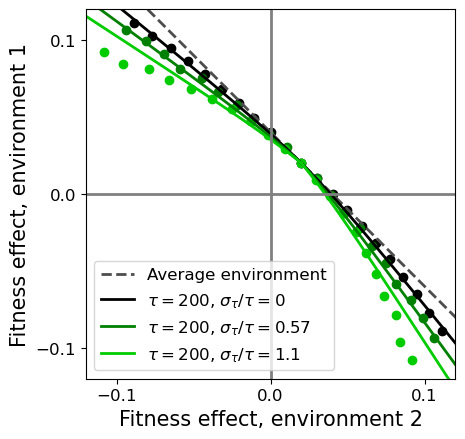

In [43]:
def sbar_frequent_deterministic(sg, s_tradeoff, tau, xc, vpar):
    target = np.log(pfix_frequent_deterministic_time(sg, s_tradeoff, tau, xc, vpar, 0, None))
    f = lambda sb: np.log(pfix_frequent_deterministic_time(sg, s_tradeoff, tau, xc, vpar, 1, None, sbar = sb)) - target
    return newton(f, sg)

def sbar_frequent_stochastic(sg, s_tradeoff, tau, xc, vpar, sigma_tau):
    f = lambda sb: np.log(pfix_ratio_frequent_stochastic_simple(sg, s_tradeoff, tau, xc, vpar, sigma_tau, sbar = sb))
    sbar_target = newton(f, sg)
    sbar_adjustment = sbar_frequent_deterministic(sg, s_tradeoff, tau, xc, vpar)
    return sbar_target + sbar_adjustment - sg

sg = 0.02
ug = 3e-9
period = 400
tau = period/2

xc_est = vpar_est/sg * np.log(sg/ug) + sg/2

s_tradeoff_vals = np.array(s_tradeoff_vals)
s_tradeoff_theory = np.linspace(0,0.15,100)

vpar_pred_interp = interp1d(s_tradeoff_vals, vpar_est[:,0], kind='linear', fill_value='extrapolate')(s_tradeoff_theory)
xc_pred_interp = interp1d(s_tradeoff_vals, xc_est[:,0], kind='linear', fill_value='extrapolate')(s_tradeoff_theory)
vpar_pred_interp[s_tradeoff_theory < s_tradeoff_vals[0]] = vpar_est[0,0]
xc_pred_interp[s_tradeoff_theory < s_tradeoff_vals[0]] = xc_est[0,0]


plt.plot([-0.12+sg,0.12+sg],[0.12+sg,-0.12+sg], color=[0.3,0.3,0.3], linestyle = '--',linewidth=2, label='Average environment')


# Deterministic environment

sbar_theory = np.zeros_like(s_tradeoff_theory)
for i in range(0,len(s_tradeoff_theory)):
    sbar_theory[i] = sbar_frequent_deterministic(sg, s_tradeoff_theory[i], tau, xc_pred_interp[i], vpar_pred_interp[i])

x_theory = sbar_theory - s_tradeoff_theory
y_theory = sbar_theory + s_tradeoff_theory
plt.plot(x_theory, y_theory, color='black', linewidth=2, label=r'$\tau = 200$, $\sigma_\tau/\tau = 0$')
x_theory = sbar_theory + s_tradeoff_theory
y_theory = sbar_theory - s_tradeoff_theory
plt.plot(x_theory, y_theory, color='black', linewidth=2)

# Stochastic environment 1

vpar_pred_interp = interp1d(s_tradeoff_vals, vpar_est[:,1], kind='linear', fill_value='extrapolate')(s_tradeoff_theory)
xc_pred_interp = interp1d(s_tradeoff_vals, xc_est[:,1], kind='linear', fill_value='extrapolate')(s_tradeoff_theory)
vpar_pred_interp[s_tradeoff_theory < s_tradeoff_vals[0]] = vpar_est[0,1]
xc_pred_interp[s_tradeoff_theory < s_tradeoff_vals[0]] = xc_est[0,1]

sbar_theory = np.zeros_like(s_tradeoff_theory)
for i in range(0,len(s_tradeoff_theory)):
    sbar_theory[i] = sbar_frequent_stochastic(sg, s_tradeoff_theory[i], tau, xc_pred_interp[i], vpar_pred_interp[i], 0.4*period/np.sqrt(2))

x_theory = sbar_theory - s_tradeoff_theory
y_theory = sbar_theory + s_tradeoff_theory
plt.plot(x_theory, y_theory, color=[0,0.5,0], linewidth=2, label=r'$\tau = 200$, $\sigma_\tau/\tau = 0.57$')
x_theory = sbar_theory + s_tradeoff_theory
y_theory = sbar_theory - s_tradeoff_theory
plt.plot(x_theory, y_theory, color=[0,0.5,0], linewidth=2)

# Stochastic environment 2

vpar_pred_interp = interp1d(s_tradeoff_vals, vpar_est[:,2], kind='linear', fill_value='extrapolate')(s_tradeoff_theory)
xc_pred_interp = interp1d(s_tradeoff_vals, xc_est[:,2], kind='linear', fill_value='extrapolate')(s_tradeoff_theory)
vpar_pred_interp[s_tradeoff_theory < s_tradeoff_vals[0]] = vpar_est[0,2]
xc_pred_interp[s_tradeoff_theory < s_tradeoff_vals[0]] = xc_est[0,2]

sbar_theory = np.zeros_like(s_tradeoff_theory)
for i in range(0,len(s_tradeoff_theory)):
    sbar_theory[i] = sbar_frequent_stochastic(sg, s_tradeoff_theory[i], tau, xc_pred_interp[i], vpar_pred_interp[i], 0.8*period/np.sqrt(2))

x_theory = sbar_theory - s_tradeoff_theory
y_theory = sbar_theory + s_tradeoff_theory
plt.plot(x_theory, y_theory, color=[0,0.8,0], linewidth=2, label=r'$\tau = 200$, $\sigma_\tau/\tau = 1.1$')
x_theory = sbar_theory + s_tradeoff_theory
y_theory = sbar_theory - s_tradeoff_theory
plt.plot(x_theory, y_theory, color=[0,0.8,0], linewidth=2)

plt.scatter(iso1D, iso2D, color='black', marker='o')
plt.scatter(iso1E, iso2E, color=[0,0.5,0], marker='o')
plt.scatter(iso1F, iso2F, color=[0,0.8,0], marker='o')

plt.plot([-0.12,0.12],[0,0], color='gray', linewidth=2)
plt.plot([0,0],[-0.12,0.12], color='gray', linewidth=2)


plt.xlabel('Fitness effect, environment 2',fontsize=15)
plt.ylabel('Fitness effect, environment 1',fontsize=15)
plt.axis('square')
plt.xlim([-0.12, 0.12])
plt.ylim([-0.12, 0.12])
plt.xticks([-0.1,0,0.1],fontsize=12)
plt.yticks([-0.1,0,0.1],fontsize=12)
plt.legend(fontsize=12, loc='lower left')
#plt.savefig(r'Figures\6C_Frequent_Fixation_Isoclines.pdf', format='pdf')
plt.show()